# Customer-Base Audit

Derived from *The Customer-Base Audit: An Excel-Based Companion* (Fader, Hardie, Ross, v1.0).

Quarterly aggregated data is provided by **Madrigal** and represents a 1% sample of data from **Q1 2016 - Q4 2019** (16 quarters) of **70,041 customers**.

Product-dimension analyses (TCBA Ch. 8) are out of scope.

## Imports

In [1]:
import numpy as np
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
from great_tables import GT, loc, style
from IPython.display import display

%config InlineBackend.figure_formats = ['svg']

## Data

### Long Format

`cust_data_long.csv` — one row per customer × quarter *in which the customer was active*. ~130,789 rows.

| Column | Meaning |
|---|---|
| `CustomerID` | customer key |
| `Cohort` | acquisition quarter, e.g. `y2016 q1`; also `pre y2016` for customers acquired before the observation window |
| `YearQuarter` | `y2016 q1` … `y2019 q4` |
| `NumTrans` | transactions in that quarter |
| `Spend` | revenue in that quarter |
| `Profit` | contribution profit in that quarter |

Derive `Year` from the first 5 characters of `YearQuarter` (`y2016` … `y2019`).

In [2]:
cust_data = pd.read_csv("data/madrigal/cust_data_long.csv")
cust_data = (
    cust_data
    .assign(
        Spend=lambda x: (x["Spend"] * 100).round().astype("int64"),
        Profit=lambda x: (x["Profit"] * 100).round().astype("int64"),
    )
    .assign(
        **cust_data["YearQuarter"]
        .str.extract(r"y(\d{4})_q(\d)")
        .rename(columns={0: "Year", 1: "Quarter"})
        .astype({
            "Year": "int32", 
            "Quarter": "int8"
        })
    )
    .drop(columns="YearQuarter")
)

### Wide to Long format

Three files — `cust_by_qtr_trans.csv`, `cust_by_qtr_spend.csv`, `cust_by_qtr_profit.csv` — one row per customer, one column per quarter, plus a `Cohort` column. Mostly zeros/blanks. If you use these, **do not assume the three files share the same CustomerID ordering — verify.**

In this exercise, we will be using the long format data. However, if you only have wide format data, you can create a long format dataframe with the following steps:

```python
from functools import reduce

def wide_to_long(wide_df, value):
    long_data = wide_df.melt(
        id_vars=["CustomerID", "Cohort"], 
        value_vars=wide_df.columns[2:], 
        var_name="YearQuarter", 
        value_name=value
    ).sort_values(
        ["CustomerID", "YearQuarter"]
    )
    
    if value == "NumTrans":
        long_data = long_data.query(
            "NumTrans > 0"
        ).astype({"NumTrans": "int32"})
    
    return long_data.reset_index(drop=True)

trans_wide = pd.read_csv("data/madrigal/cust_by_qtr_trans.csv")
spend_wide = pd.read_csv("data/madrigal/cust_by_qtr_spend.csv")
profit_wide = pd.read_csv("data/madrigal/cust_by_qtr_profit.csv")

cust_data_long = reduce(
    lambda left, right: left.merge(
        right,
        on=["CustomerID", "Cohort", "YearQuarter"],
        how="left",
    ),
    (
        wide_to_long(df, value)
        for df, value in [
            (trans_wide, "NumTrans"),
            (spend_wide, "Spend"),
            (profit_wide, "Profit"),
        ]
    ),
)
```

### Data Conventions

- **Cohort** = customers acquired in a given period (quarter or year).
- **Cohort size** = number of customers whose acquisition period is that period (diagonal of a cohort × period active-customer matrix). Size of the `pre y2016` cohort is **unknown** — exclude it from any %-active or per-cohort-size calculation.
- **AOF** (average order frequency) = total transactions ÷ number of active customers.
- **AOV** (average order value) = total spend ÷ total transactions.
- **Average margin** = total profit ÷ total spend.
- Core multiplicative decomposition of profit:

  ```
  Profit = #customers × AOF × AOV × Margin
         = #customers × (trans/cust) × (spend/trans) × (profit/spend)
  ```

- For cohorts in a period, the decomposition extends to:

  ```
  Cohort profit = cohort size × % cohort active × AOF × AOV × Margin
  Cohort revenue = cohort size × % cohort active × ASPAC
  ASPAC (avg spend per active cohort member) = AOF × AOV
  ```

### Histogram Binning Conventions

- Bins are **half-open on the left**: the `$25–50` bin counts spend in `(25, 50]`. The first bin is inclusive of its lower edge, so a customer with $0 spend falls in the first bin.
- Behavioural distributions are heavily right-skewed (max often 10–100× the mean), so every histogram gets a **right-censoring point** — a terminal `> x` bin.
- Choose bin width from the percentile table, not by rule of thumb. Preferred widths: 1, 2, 5, 10, 20, 25, 50, 100, 200, 250, 500. Too narrow → noisy; too wide → hides the skew.
- Choose the censoring point so the final bin isn't overloaded. If ~5% of customers exceed $578, censoring at $600 puts too much mass in the last bin; $1000 is better.
- Plot **relative frequencies**, not counts, whenever you compare two groups of different size.
- In Python, prefer `np.histogram` with explicit `bins=` edges, or `pd.cut(..., right=True)`.

## Lens 1 — How do customers differ from one another? (single period)

**Objective:** quantify variability in buying behaviour across customers within one calendar year (e.g. 2019). Answer: the "average customer" is a fiction.

### Working dataset

Filter long data to `Year == y2019`, group by `CustomerID`, sum `NumTrans`, `Spend`, `Profit`. Only customers with ≥1 transaction in 2019 appear.

**Validation targets**

| Metric | Value |
|---|---|
| Active customers, 2019 | 31,855 |
| Total transactions | 60,730 |
| Total spend | ≈ $5,836,712 |
| Total profit | ≈ $2,798,904 |
| Avg transactions / active customer | 1.9 |
| Avg spend / active customer | $183 |
| Avg profit / active customer | $88 |

In [3]:
def yearly_cust_data(df, year):
    
    return (
        df
        .query(f"Year == {year}")
        .groupby("CustomerID", as_index=False)
        .agg(
            NumTrans=("NumTrans", "sum"),
            Spend=("Spend", "sum"),
            Profit=("Profit", "sum"),
        ).assign(
            Spend=lambda x: (x["Spend"] / 100).astype("float32").round(2),
            Profit=lambda x: (x["Profit"] / 100).astype("float32").round(2)
        )
    )

In [4]:
cust_data_2019 = yearly_cust_data(df=cust_data ,year=2019)

summary = {
    "Active Customers": len(cust_data_2019),
    "Total Transactions": cust_data_2019["NumTrans"].sum(),
    "Total Spend": cust_data_2019["Spend"].sum(),
    "Total Profit": cust_data_2019["Profit"].sum(),
    "Avg. Transactions / Active Customer": cust_data_2019["NumTrans"].mean(),
    "Avg. Spend / Active Customer": cust_data_2019["Spend"].mean(),
    "Avg. Profit / Active Customer": cust_data_2019["Profit"].mean(),
}

summary = (
    pd.DataFrame(summary.items(), columns=["Metric", "Value"])
)

(
    GT(summary)
    .tab_header(
        title="2019 Annual Customer Summary",
        subtitle="Customer activity, revenue, and profitability metrics"
    )
    .fmt_number(
        columns="Value",
        rows=[0, 1],
        decimals=0
    ).fmt_currency(
        columns="Value",
        rows=[2, 3],
        decimals=0
    ).fmt_currency(
        columns="Value",
        rows=[4, 5, 6],
        decimals=2
    ).fmt_number(
        columns="Value",
        rows=[4],
        decimals=2
    ).tab_options(
            table_font_size="12px",
            data_row_padding="4px"
    )
)

GT(_tbl_data=                                Metric         Value
0                     Active Customers  3.185500e+04
1                   Total Transactions  6.073000e+04
2                          Total Spend  5.836712e+06
3                         Total Profit  2.798904e+06
4  Avg. Transactions / Active Customer  1.906451e+00
5         Avg. Spend / Active Customer  1.832275e+02
6        Avg. Profit / Active Customer  8.786388e+01, _body=<great_tables._gt_data.Body object at 0x7dd90cda8980>, _boxhead=Boxhead([ColInfo(var='Metric', type=<ColInfoTypeEnum.default: 1>, column_label='Metric', column_align='left', column_width=None), ColInfo(var='Value', type=<ColInfoTypeEnum.default: 1>, column_label='Value', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90cda8590>, _spanners=Spanners([]), _heading=Heading(title='2019 Annual Customer Summary', subtitle='Customer activity, revenue, and profitability metrics', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90cda8830>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90cd0dd10>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90cda8050>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90cda86e0>, <great_tables._gt_data.FormatInfo object at 0x7dd90cd0e490>, <great_tables._gt_data.FormatInfo object at 0x7dd90cd0e990>, <great_tables._gt_data.FormatInfo object at 0x7dd90cd90770>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8

### Foundational Plots

#### Helper Functions

In [5]:
def customer_descriptives(df, metric):
    s = df[metric]

    mean = s.mean()

    return {
        "count": s.count(),
        "mean": mean,
        "median": s.median(),
        "std": s.std(),
        "min": s.min(),
        "max": s.max(),
        "pct_below_mean": (s < mean).mean(),
        "percentiles": s.quantile([i / 100 for i in range(5, 100, 5)])
    }

def create_percentile_table(df, column, title, subtitle=None, format=None):
    percentile_table = (
        df["percentiles"]
        .reset_index()
        .rename(columns={
            "index": "Percentile",
            column: "Value"
        })
    )

    percentile_table["Percentile"] = (
        percentile_table["Percentile"] * 100
    ).astype(int).astype(str) + "%"


    gt_table = (
        GT(percentile_table)
        .tab_header(
            title=title,
            subtitle=subtitle
        ).tab_options(
            table_font_size="12px",
            data_row_padding="4px"
        )
    )
    
    if format == "currency":
        gt_table = gt_table.fmt_currency(columns="Value", decimals=2)
    elif format == "pct":
        gt_table = gt_table.fmt_percent(columns='Value', decimals=2)
    elif format == "float":
        gt_table = gt_table.fmt_number(columns="Value", decimals=2)
    
    return percentile_table, gt_table

def create_bins_labels(bin_width, max_cutoff, min_cutoff=None):
    if min_cutoff is None:
        min_cutoff = 0
        lower_bins = []
        lower_labels = []
    else:
        lower_bins = [-np.inf]
        lower_labels = [f"<{min_cutoff}"]

    bins = (
        lower_bins
        + list(range(min_cutoff, max_cutoff + bin_width, bin_width))
        + [np.inf]
    )
    
    labels = (
        lower_labels
        + [
            f"{i}-{i+bin_width}"
            for i in range(min_cutoff, max_cutoff, bin_width)
        ]
        + [f"{max_cutoff}+"]
    )
    
    return {"bins": bins, "labels": labels}

def create_distribution(df, column, bins, labels):
    distribution = (
        pd.cut(
            df[column],
            bins=bins,
            labels=labels,
            right=False
        )
        .value_counts()
        .sort_index()
        .reset_index()
        .rename(columns={
            "count": "Customers",
            column: f"{column} Range"
        })
    )

    distribution["Percent"] = (
        distribution["Customers"]
        / distribution["Customers"].sum()
    )

    return distribution


def distribution_barplot(
    distribution,
    column,
    title="Customer Distribution",
    x_title="Range",
    width=800,
    height=400,
    series=None,
    opacity=1.0,
):
    data = (
        distribution
        .rename(columns={f"{column} Range": "Range"})
        .astype({"Range": str})
    )
    order = data["Range"].tolist()

    encodings = {
        "x": alt.X(
            "Range:N",
            title=x_title,
            sort=order,
            axis=alt.Axis(
                labelAngle=-45,
                grid=False
            )
        ),
        "y": alt.Y(
            "Percent:Q",
            title="Customers (%)",
            axis=alt.Axis(
                format="%",
                grid=False
            )
        ),
        "tooltip": [
            alt.Tooltip("Range:N", title="Range"),
            alt.Tooltip("Customers:Q", title="Customers", format=","),
            alt.Tooltip("Percent:Q", title="Customers (%)", format=".1%"),
        ],
    }

    if series is not None:
        data = data.assign(Series=series)
        encodings["color"] = alt.Color("Series:N", title=None)
        encodings["tooltip"] = (
            [alt.Tooltip("Series:N", title="Series")] + encodings["tooltip"]
        )

    return (
        alt.Chart(data)
        .mark_bar(opacity=opacity)
        .encode(**encodings)
        .properties(
            title=title,
            width=width,
            height=height,
        )
    )


def overlay_distributions(
    *charts,
    series=None,
    title="Customer Distribution",
    opacity=0.6,
):
    if series is None:
        series = [None] * len(charts)
    elif len(series) != len(charts):
        raise ValueError(
            f"got {len(series)} series labels for {len(charts)} charts"
        )

    layers = []
    for chart, label in zip(charts, series):
        layer = chart.mark_bar(opacity=opacity).properties(title="")
        # Label here rather than in distribution_barplot, so a layer only
        # needs a name once it sits next to another one.
        if label is not None:
            layer = layer.transform_calculate(
                Series=alt.expr.toString(label)
            ).encode(
                color=alt.Color("Series:N", title=None),
                tooltip=[
                    alt.Tooltip("Series:N", title="Series"),
                    alt.Tooltip("Range:N", title="Range"),
                    alt.Tooltip("Customers:Q", title="Customers", format=","),
                    alt.Tooltip("Percent:Q", title="Customers (%)", format=".1%"),
                ],
            )
        layers.append(layer)

    return alt.layer(*layers).properties(title=title)


#### Distribution of Spend

Descriptives first (min, max, mean, median, % below mean), then percentiles at 5% intervals (5%…95%), then bin.

**Findings:** max $6,695 ≈ 37× the mean. Mean $183 > median $113. **69% of customers spend below average.** 5th pct $22.20; 10th pct $30.22; the top 5% each spent more than $578.52.

**Bins:** width $25, censor at $1000 → 41 bins. (Width $20 → 51 bins, also defensible.)

**Note:** two customers have exactly $0 spend in 2019; they land in the first bin.

In [6]:
spend_stats = customer_descriptives(cust_data_2019, "Spend")

print(
    f"{'Min spend:':<15}${spend_stats['min']:,.2f}"
    f"\n{'Max spend:':<15}${spend_stats['max']:,.2f}"
    f"\n{'Mean spend:':<15}${spend_stats['mean']:,.2f}"
    f"\n{'Median spend:':<15}${spend_stats['median']:,.2f}"
    f"\n{'% below avg.:':<15}{spend_stats['pct_below_mean']:.1%}"
)

Min spend:     $0.00
Max spend:     $6,695.02
Mean spend:    $183.23
Median spend:  $113.95
% below avg.:  69.2%


In [7]:
print(
    f"Mean spend ${spend_stats['mean']:,.0f} is "
    f"{spend_stats['mean']/spend_stats['median']:.1f}× "
    f"the median spend of ${spend_stats['median']:,.0f}."
)

print(
    f"\n{spend_stats['pct_below_mean']:.0%} of customers "
    f"spent below the average."
)

p = spend_stats["percentiles"]

print(
    f"\nThe bottom 5% of customers spent "
    f"${p.loc[0.05]:,.2f} or less."
)

print(
    f"\nThe bottom 10% of customers spent "
    f"${p.loc[0.10]:,.2f} or less."
)

print(
    f"\nThe top 5% of customers spent more than "
    f"${p.loc[0.95]:,.2f}."
)

Mean spend $183 is 1.6× the median spend of $114.

69% of customers spent below the average.

The bottom 5% of customers spent $22.20 or less.

The bottom 10% of customers spent $30.22 or less.

The top 5% of customers spent more than $578.52.


In [8]:
_, gt_table = create_percentile_table(
    spend_stats, 
    "Spend", 
    title="Customer Spend Distribution",
    subtitle="2019 annual spend percentiles",
    format="currency"
)
gt_table

GT(_tbl_data=   Percentile       Value
0          5%   22.197001
1         10%   30.219999
2         15%   39.599998
3         20%   48.000000
4         25%   57.590000
5         30%   64.790001
6         35%   73.929000
7         40%   86.389999
8         45%   98.906001
9         50%  113.949997
10        55%  126.459999
11        60%  144.000000
12        65%  165.784000
13        70%  188.399994
14        75%  216.370003
15        80%  255.520004
16        85%  311.980011
17        90%  396.951996
18        95%  578.521991, _body=<great_tables._gt_data.Body object at 0x7dd90cd90e90>, _boxhead=Boxhead([ColInfo(var='Percentile', type=<ColInfoTypeEnum.default: 1>, column_label='Percentile', column_align='right', column_width=None), ColInfo(var='Value', type=<ColInfoTypeEnum.default: 1>, column_label='Value', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90cd0f250>, _spanners=Spanners([]), _heading=Heading(title='Customer Spend Distribution', subtitle='2019 annual spend percentiles', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90cd0f750>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90cd909d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90cd0fb10>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90cd91220>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), t

In [9]:
distribution_barplot(
    create_distribution(
        cust_data_2019, 
        column="Spend", 
        **create_bins_labels(bin_width=25, max_cutoff=1000)
    ),
    column="Spend",
    title="Customer Spend Distribution (2019)",
    x_title="Annual Spend ($)"
)

alt.Chart(...)

#### Distribution of Profit

Same structure, but with an explicit **`< $0` bin** for loss-making customers.

**Findings:** range –$652 to $3,347. Mean $88 > median $54; again **69% below average**. 5th pct $7.70; 10th pct $12.47; top 5% above $282.45.

**Bins:** width $25, censor at $500, plus the `<0` bin. (Profit mean/median/max run ~45–50% of the corresponding spend figures, which is what motivates the lower cut-off.)


In [10]:
profit_stats = customer_descriptives(cust_data_2019, "Profit")

print(
    f"{'Min profit:':<15}${profit_stats['min']:,.2f}"
    f"\n{'Max profit:':<15}${profit_stats['max']:,.2f}"
    f"\n{'Mean profit:':<15}${profit_stats['mean']:,.2f}"
    f"\n{'Median profit:':<15}${profit_stats['median']:,.2f}"
    f"\n{'% below avg.:':<15}{profit_stats['pct_below_mean']:.1%}"
)

Min profit:    $-651.62
Max profit:    $3,347.09
Mean profit:   $87.86
Median profit: $52.40
% below avg.:  68.7%


In [11]:
print(
    f"The mean profits represent {profit_stats['mean'] / spend_stats['mean'] * 100:,.2f}% of mean spend."
    f"\nThe median profits represent {profit_stats['median'] / spend_stats['median'] * 100:,.2f}% of median spend."
    f"\nThe max profits represent {profit_stats['max'] / spend_stats['max'] * 100:,.2f}% of median spend."
    f"\nThis is approximately 45-50% profit margins for corresponding spend numbers"
)

The mean profits represent 47.95% of mean spend.
The median profits represent 45.99% of median spend.
The max profits represent 49.99% of median spend.
This is approximately 45-50% profit margins for corresponding spend numbers


In [12]:
_, gt_table = create_percentile_table(
    profit_stats, 
    "Profit", 
    title="Customer Profit Distribution",
    subtitle="2019 annual profit percentiles",
    format="currency"
)
gt_table

GT(_tbl_data=   Percentile       Value
0          5%    7.697000
1         10%   12.474000
2         15%   16.681000
3         20%   20.830000
4         25%   24.760000
5         30%   29.110001
6         35%   34.009998
7         40%   39.246001
8         45%   45.689999
9         50%   52.400002
10        55%   60.259998
11        60%   69.353999
12        65%   79.411003
13        70%   90.998000
14        75%  105.959999
15        80%  125.510002
16        85%  153.607001
17        90%  195.881998
18        95%  282.449002, _body=<great_tables._gt_data.Body object at 0x7dd90ba719d0>, _boxhead=Boxhead([ColInfo(var='Percentile', type=<ColInfoTypeEnum.default: 1>, column_label='Percentile', column_align='right', column_width=None), ColInfo(var='Value', type=<ColInfoTypeEnum.default: 1>, column_label='Value', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90cd0f610>, _spanners=Spanners([]), _heading=Heading(title='Customer Profit Distribution', subtitle='2019 annual profit percentiles', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90ba98d60>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90ba6a450>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90ba1afd0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90ba6a7b0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'),

In [13]:
distribution_barplot(
    create_distribution(
        cust_data_2019, 
        column="Profit",
        **create_bins_labels(
            bin_width=25, 
            max_cutoff=500, 
            min_cutoff=0
        )
    ),
    column="Profit",
    title="Customer Profit Distribution (2019)",
    x_title="Annual Profit ($)"
)

alt.Chart(...)

#### Distribution of Number of Transactions

Simple value-count of `NumTrans`.

**Findings:** right-skewed (reverse-J). Max = 58 transactions. **63% of customers made exactly one purchase** (20,149 / 31,855), so the mean of 1.9 is misleading.

**Bins:** width 1, censor at `10+`. (Censoring at 5 is too low — 6.8% of customers made ≥5 transactions.) Keep all non-terminal bins **equal width**; do not do 1 / 2–4 / 5–9 / 10+. If you want unequal groupings, use a table, not a histogram.

In [14]:
trans_stats = customer_descriptives(cust_data_2019, "NumTrans")

print(
    f"{'Min trans.:':<15}{trans_stats['min']:,.0f}"
    f"\n{'Max trans.:':<15}{trans_stats['max']:,.0f}"
    f"\n{'Mean trans.:':<15}{trans_stats['mean']:,.2f}"
    f"\n{'Median trans.:':<15}{trans_stats['median']:,.2f}"
    f"\n{'% below avg.:':<15}{trans_stats['pct_below_mean']:.1%}"
)

Min trans.:    1
Max trans.:    58
Mean trans.:   1.91
Median trans.: 1.00
% below avg.:  63.3%


In [15]:
_, gt_table = create_percentile_table(
    trans_stats, 
    "NumTrans", 
    title="Customer Transactions Distribution",
    subtitle="2019 annual transactions percentiles"
)
gt_table

GT(_tbl_data=   Percentile  Value
0          5%    1.0
1         10%    1.0
2         15%    1.0
3         20%    1.0
4         25%    1.0
5         30%    1.0
6         35%    1.0
7         40%    1.0
8         45%    1.0
9         50%    1.0
10        55%    1.0
11        60%    1.0
12        65%    2.0
13        70%    2.0
14        75%    2.0
15        80%    2.0
16        85%    3.0
17        90%    4.0
18        95%    5.0, _body=<great_tables._gt_data.Body object at 0x7dd90bac5850>, _boxhead=Boxhead([ColInfo(var='Percentile', type=<ColInfoTypeEnum.default: 1>, column_label='Percentile', column_align='right', column_width=None), ColInfo(var='Value', type=<ColInfoTypeEnum.default: 1>, column_label='Value', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90ba99350>, _spanners=Spanners([]), _heading=Heading(title='Customer Transactions Distribution', subtitle='2019 annual transactions percentiles', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90ba71bf0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90ba71d00>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90ba995b0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category=

In [16]:
bins = (list(range(1, 10 + 1, 1)) + [np.inf])
labels = [str(i) for i in range(1, 10, 1)] + ["10+"]

distribution_barplot(
    create_distribution(
        cust_data_2019, 
        column="NumTrans",
        bins=bins,
        labels=labels
    ),
    column="NumTrans",
    title="Customer Transactions Distribution (2019)",
    x_title="Annual Transactions"
)

alt.Chart(...)

#### Distribution of Average Spend per Transaction


Per customer: `avg_spend = Spend / NumTrans`.

**Bins:** width $25, censor at $500. ($20 / $300 also reasonable; the $500 cut-off shows the tail better.)

**Two different "average spend per transaction" numbers**

These are **not** the same quantity and both appear in practice:

- Average spend per customer = **$183**, average transactions per customer = **1.9** → $183 / 1.9 ≈ **$96**
- Mean of each customer's own average spend per transaction = **$99**

The gap isn't an error. They are different estimators.

**AOV (Weighted-average spend per transaction value)**

Start from the ratio of the two per-customer means. The $I$ cancels, leaving total spend over total transactions:

$$
\frac{\frac{1}{I}\sum_{i=1}^{I}\text{spend}_i}{\frac{1}{I}\sum_{i=1}^{I}\text{trans}_i}
=\frac{\sum_{i=1}^{I}\text{spend}_i}{\sum_{i=1}^{I}\text{trans}_i}
$$

Now rewrite the numerator by multiplying and dividing each customer's spend by their transaction count:

$$
=\frac{\sum_{i=1}^{I}\text{trans}_i\times\dfrac{\text{spend}_i}{\text{trans}_i}}{\sum_{i=1}^{I}\text{trans}_i}
=\sum_{i=1}^{I}\left(\frac{\text{trans}_i}{\sum_{j=1}^{I}\text{trans}_j}\right)\frac{\text{spend}_i}{\text{trans}_i}
$$

So it is a weighted average of individual average spend per transaction, where each customer's weight is their **share of total transactions**. Frequent buyers dominate it.

**Unweighted mean of the per-customer average**

$$
\frac{1}{I}\sum_{i=1}^{I}\frac{\text{spend}_i}{\text{trans}_i}
$$

Every customer counts once, regardless of how much they bought. The one-and-done buyers (63% of the base) carry as much weight as the customer with 58 transactions.

**Why it matters**

The two coincide **only** when $\text{trans}_i$ is identical across all $I$ customers. That never happens in a real customer base, so the two numbers will always diverge — and the direction of the gap tells you something. Here $96 < 99$, meaning heavier buyers have *lower* average baskets than light buyers.

Naming convention from the book, worth adopting so you never confuse them again:

| Quantity | Formula | 2019 value |
|---|---|---|
| **AOV** (Average Order Value) | $\sum \text{spend}_i \big/ \sum \text{trans}_i$ | $96 |
| Mean average spend per transaction | $\frac{1}{I}\sum \text{spend}_i / \text{trans}_i$ | $99 |

"AOV" always means the transaction-weighted one. When you see an "average average spend" number in someone else's report, find out which one it is before you act on it.

In [17]:
# per-customer average spend per transaction
cust_data_2019['AvgSpendPerTrans'] = cust_data_2019['Spend'] / cust_data_2019['NumTrans']

avg_spend_stats = customer_descriptives(cust_data_2019, "AvgSpendPerTrans")

print(
    f"{'Min spend:':<15}${avg_spend_stats['min']:,.2f}"
    f"\n{'Max spend:':<15}${avg_spend_stats['max']:,.2f}"
    f"\n{'Mean spend:':<15}${avg_spend_stats['mean']:,.2f}"
    f"\n{'Median spend:':<15}${avg_spend_stats['median']:,.2f}"
    f"\n{'% below avg.:':<15}{avg_spend_stats['pct_below_mean']:.1%}"
)

Min spend:     $0.00
Max spend:     $3,450.98
Mean spend:    $99.01
Median spend:  $77.28
% below avg.:  62.6%


In [18]:
_, gt_table = create_percentile_table(
    avg_spend_stats, 
    "AvgSpendPerTrans", 
    title="Average Spend per Transactions Distribution",
    subtitle=None,
    format="currency"
)
gt_table

GT(_tbl_data=   Percentile       Value
0          5%   19.561000
1         10%   27.540001
2         15%   34.310601
3         20%   40.392000
4         25%   46.218001
5         30%   51.000000
6         35%   58.070297
7         40%   62.998000
8         45%   70.801802
9         50%   77.279999
10        55%   85.190002
11        60%   93.871999
12        65%  104.394997
13        70%  116.697002
14        75%  127.550001
15        80%  143.395505
16        85%  165.298603
17        90%  192.585999
18        95%  241.598999, _body=<great_tables._gt_data.Body object at 0x7dd90baab770>, _boxhead=Boxhead([ColInfo(var='Percentile', type=<ColInfoTypeEnum.default: 1>, column_label='Percentile', column_align='right', column_width=None), ColInfo(var='Value', type=<ColInfoTypeEnum.default: 1>, column_label='Value', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90ba99940>, _spanners=Spanners([]), _heading=Heading(title='Average Spend per Transactions Distribution', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90bac5e50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90bac5f50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90ba99ba0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90ba72250>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border

In [19]:
distribution_barplot(
    create_distribution(
        cust_data_2019, 
        column="AvgSpendPerTrans",
        **create_bins_labels(
            bin_width=25, 
            max_cutoff=500
        )
    ),
    column="AvgSpendPerTrans",
    title="Average Spend per Transactions Distribution (2019)",
    x_title="Average Spend per Transactions ($)"
)

alt.Chart(...)

### Further Analyses

#### Average Spend per Transaction, by Transaction Level

Given the variability in both the number of transactions and average spend per transaction across customers, it is natural to ask whether these two quantities are related.

Group customers by transaction count (1, 2, …, 9, `10+` — same bins as §1.3). For each group report: **mean, std dev, min, max, 5th pct, median, 95th pct** of per-customer average spend. Purpose: is average order value related to purchase frequency?

In [20]:
bins = (list(range(1, 10 + 1, 1)) + [np.inf])
labels = [str(i) for i in range(1, 10, 1)] + ["10+"]

cust_data_2019["TransBin"] = pd.cut(
    cust_data_2019["NumTrans"],
    bins=bins,
    labels=labels,
    right=False
)

avg_spend_per_trans = (
    cust_data_2019.groupby("TransBin", as_index=False)
    .agg(
        Mean=("AvgSpendPerTrans", "mean"),
        Std=("AvgSpendPerTrans", "std"),
        Min=("AvgSpendPerTrans", "min"),
        P05=("AvgSpendPerTrans", lambda s: s.quantile(0.05)),
        Median=("AvgSpendPerTrans", "median"),
        P95=("AvgSpendPerTrans", lambda s: s.quantile(0.95)),
        Max=("AvgSpendPerTrans", "max"),
    )
)

(
    GT(avg_spend_per_trans)
    .tab_header(
        title="Analysis of Average Spend per Transaction",
        subtitle="Analysis of average spend per transaction by transaction level"
    ).fmt_currency(
        columns=list(avg_spend_per_trans.columns[1:]),
        decimals=2
    ).tab_options(
            table_font_size="12px",
            data_row_padding="4px"
    )
)

GT(_tbl_data=  TransBin        Mean        Std        Min        P05     Median  \
0        1   99.861561  90.694898   0.000000  18.000000  72.000000   
1        2  100.386581  82.554953   6.880000  23.992250  81.577499   
2        3   99.119952  68.540378   7.763334  26.647667  83.789998   
3        4   96.915875  65.582179   8.820000  27.596250  82.794998   
4        5   91.191284  53.842962   9.788000  27.397600  78.459998   
5        6   91.420917  55.223779  10.958333  25.871334  80.773336   
6        7   86.971100  48.802187  11.281429  27.151357  77.012142   
7        8   88.048181  50.486003  11.250000  29.141250  78.307503   
8        9   81.849074  43.786769  11.311111  24.472666  71.812225   
9      10+   83.371158  43.830915  12.105000  28.944381  74.278184   

          P95          Max  
0  252.444000  3450.979980  
1  231.573000  2544.840088  
2  218.472004   809.533366  
3  206.459999   723.537476  
4  191.167197   400.087988  
5  192.859338   415.456665  
6  180.260147   277.951433  
7  186.086496   339.752502  
8  159.690782   275.942220  
9  167.556258   268.252730  , _body=<great_tables._gt_data.Body object at 0x7dd90bab90d0>, _boxhead=Boxhead([ColInfo(var='TransBin', type=<ColInfoTypeEnum.default: 1>, column_label='TransBin', column_align='center', column_width=None), ColInfo(var='Mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='right', column_width=None), ColInfo(var='Std', type=<ColInfoTypeEnum.default: 1>, column_label='Std', column_align='right', column_width=None), ColInfo(var='Min', type=<ColInfoTypeEnum.default: 1>, column_label='Min', column_align='right', column_width=None), ColInfo(var='P05', type=<ColInfoTypeEnum.default: 1>, column_label='P05', column_align='right', column_width=None), ColInfo(var='Median', type=<ColInfoTypeEnum.default: 1>, column_label='Median', column_align='right', column_width=None), ColInfo(var='P95', type=<ColInfoTypeEnum.default: 1>, column_label='P95', column_align='right', column_width=None), ColInfo(var='Max', type=<ColInfoTypeEnum.default: 1>, column_label='Max', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90ba6ae70>, _spanners=Spanners([]), _heading=Heading(title='Analysis of Average Spend per Transaction', subtitle='Analysis of average spend per transaction by transaction level', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90bab3f20>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90bab3e30>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90ba6b0b0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90ba72580>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_co

#### Distribution of Average Margin

Per customer: `margin = Profit / Spend`, defined only where `Spend > 0` (two customers have zero spend — exclude them / set NaN, don't zero-fill).

**Caveat:** this is the *overall* margin across all of a customer's 2019 purchasing, not the average of their transaction-level margins. Transaction-level margins aren't recoverable because the source data is aggregated to the quarter.

**Findings:** unlike the other four distributions, margin is **left-skewed**.

**Bins:** width 5%, plus a `< 0%` bin for loss-makers. The book keeps the (85,90], (90,95], (95,100] bins visible even though they're empty — your call.

In [21]:
cust_data_2019 = (
    cust_data_2019
    .assign(Margin=lambda x: x["Profit"] / x["Spend"] * 100)
)

avg_margin_stats = customer_descriptives(cust_data_2019.query("Spend > 0"), "Margin")

print(
    f"{'Min margin:':<15}{avg_margin_stats['min']:,.2f}"
    f"\n{'Max margin:':<15}{avg_margin_stats['max']:,.2f}"
    f"\n{'Mean margin:':<15}{avg_margin_stats['mean']:,.2f}"
    f"\n{'Median margin:':<15}{avg_margin_stats['median']:,.2f}"
    f"\n{'% below avg.:':<15}{avg_margin_stats['pct_below_mean']:.1%}"
)

Min margin:    -366.67
Max margin:    83.33
Mean margin:   46.52
Median margin: 48.38
% below avg.:  40.4%


In [22]:
_, gt_table = create_percentile_table(
    avg_margin_stats, 
    "Margin", 
    title="Average Margin (%) Distribution",
    subtitle=None,
    format="float"
)

gt_table

GT(_tbl_data=   Percentile      Value
0          5%  26.602958
1         10%  34.406146
2         15%  38.347302
3         20%  40.923367
4         25%  42.604195
5         30%  44.054952
6         35%  45.316807
7         40%  46.436002
8         45%  47.455312
9         50%  48.382793
10        55%  49.329439
11        60%  50.302261
12        65%  51.250000
13        70%  52.344319
14        75%  53.419338
15        80%  54.705596
16        85%  56.000000
17        90%  57.574085
18        95%  59.913370, _body=<great_tables._gt_data.Body object at 0x7dd90ccb97b0>, _boxhead=Boxhead([ColInfo(var='Percentile', type=<ColInfoTypeEnum.default: 1>, column_label='Percentile', column_align='right', column_width=None), ColInfo(var='Value', type=<ColInfoTypeEnum.default: 1>, column_label='Value', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90ba72be0>, _spanners=Spanners([]), _heading=Heading(title='Average Margin (%) Distribution', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90baabaf0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90baab150>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90ba72ad0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90bac6350>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=Tru

In [23]:
distribution_barplot(
    create_distribution(
        cust_data_2019.query("Spend > 0"), 
        column="Margin",
        **create_bins_labels(
            bin_width=5, 
            max_cutoff=100,
            min_cutoff=0
        )
    ),
    column="Margin",
    title="Average Margin Distribution (2019)",
    x_title="Margin (%)"
)

alt.Chart(...)

### Decile analyses

#### Customer decile report — each decile = 10% of *customers*

1. Sort customers by 2019 profit, descending.
2. Rank 1…N.
3. `decile = int(10 * (rank - 1) / N) + 1` — note the `rank - 1`, which is what keeps decile 1 from being off by one customer.
4. Aggregate by decile: customer count, total transactions, total spend, total profit.
5. Then apply the profit decomposition to produce the report columns:

| Column | Formula |
|---|---|
| % of customers | decile customers / total customers |
| % of transactions | decile trans / total trans |
| % of revenue | decile spend / total spend |
| % of profit | decile profit / total profit |
| Avg spend per customer | decile spend / decile customers |
| Avg profit per customer | decile profit / decile customers |
| AOF | decile trans / decile customers |
| AOV | decile spend / decile trans |
| Avg margin | decile profit / decile spend |

The bottom row (totals) gives the firm-level AOF/AOV/margin.

```mermaid
flowchart LR
    P["Profit"] --> X1(("×"))
    X1 --> NC["# Customers"]
    X1 --> APC["Average profit<br/>per customer"]

    APC --> X2(("×"))
    X2 --> AM["Average<br/>margin"]
    X2 --> ASC["Average spend<br/>per customer"]

    ASC --> X3(("×"))
    X3 --> AOF["Average order<br/>frequency (AOF)"]
    X3 --> AOV["Average order<br/>value (AOV)"]

    classDef box fill:#ffffff,stroke:#333,stroke-width:1.5px,color:#000
    classDef op fill:#333,stroke:#333,color:#fff
    class P,NC,APC,AM,ASC,AOF,AOV box
    class X1,X2,X3 op
```

In [24]:
cust_data_2019['ProfitRank'] = (
    pd.qcut(
        cust_data_2019['Profit'].rank(method='first', ascending=False
    ), q=10, labels=False) + 1
)

profit_rank = (
    cust_data_2019
    .groupby("ProfitRank", as_index=False)
    .agg(
        Customers=("CustomerID", "count"),
        Transactions=("NumTrans", "sum"),
        Spend=("Spend", "sum"),
        Profit=("Profit", "sum"),
    )
    .assign(
        PctCust=lambda x: x["Customers"] / x["Customers"].sum(),
        PctTrans=lambda x: x["Transactions"] / x["Transactions"].sum(),
        PctSpend=lambda x: x["Spend"] / x["Spend"].sum(),
        PctProfit=lambda x: x["Profit"] / x["Profit"].sum(),
        AvgSpendCust=lambda x: x["Spend"] / x["Customers"],
        AvgProfitCust=lambda x: x["Profit"] / x["Customers"],
        AOF=lambda x: x["Transactions"] / x["Customers"],
        AOV=lambda x: x["Spend"] / x["Transactions"],
        AvgMargin=lambda x: x["Profit"] / x["Spend"],
    ).drop(
        columns=["Customers", "Transactions", "Spend", "Profit"]
    )
)

fields = ["Decile", "% Cust.", "% Trans.", "% Spend", "% Profit", "Avg Spend/Cust.", "Avg. Profit/Cust.", "AOF", "AOV", "Avg. Margin"]
profit_rank = profit_rank.rename(columns={old: new for old, new in zip(profit_rank.columns, fields)})

(
    GT(profit_rank)
    .tab_header(
        title="Customer Decile Report"
    ).fmt_percent(
        columns=fields[1:5]+[fields[-1]], 
        decimals=1
    ).fmt_currency(
        columns=fields[5:7]+[fields[8]]
    ).fmt_number(
        columns=fields[7]
    ).tab_options(
            table_font_size="12px",
            data_row_padding="4px"
    )
)

GT(_tbl_data=   Decile   % Cust.  % Trans.   % Spend  % Profit  Avg Spend/Cust.  \
0       1  0.100016  0.266030  0.382369  0.397190       700.495763   
1       2  0.099984  0.139272  0.171904  0.176880       315.025334   
2       3  0.100016  0.106735  0.118863  0.121452       217.755787   
3       4  0.099984  0.089379  0.090174  0.090719       165.249941   
4       5  0.100016  0.081113  0.070586  0.068927       129.312431   
5       6  0.099984  0.071793  0.054100  0.051998        99.141856   
6       7  0.099984  0.066343  0.041414  0.038743        75.893686   
7       8  0.100016  0.062095  0.031342  0.028324        57.417628   
8       9  0.099984  0.058604  0.022523  0.018962        41.275216   
9      10  0.100016  0.058637  0.016724  0.006804        30.638541   

   Avg. Profit/Cust.       AOF         AOV  Avg. Margin  
0         348.931929  5.070935  138.139360     0.498121  
1         155.438255  2.655573  118.628008     0.493415  
2         106.695788  2.034526  107.030228     0.489979  
3          79.721949  1.704239   96.964087     0.482433  
4          60.552647  1.546139   83.635689     0.468266  
5          45.694211  1.368917   72.423581     0.460897  
6          34.046767  1.264992   59.995381     0.448611  
7          24.882790  1.183616   48.510359     0.433365  
8          16.663074  1.117425   36.937781     0.403707  
9           5.977492  1.117702   27.412073     0.195097  , _body=<great_tables._gt_data.Body object at 0x7dd90babdbe0>, _boxhead=Boxhead([ColInfo(var='Decile', type=<ColInfoTypeEnum.default: 1>, column_label='Decile', column_align='right', column_width=None), ColInfo(var='% Cust.', type=<ColInfoTypeEnum.default: 1>, column_label='% Cust.', column_align='right', column_width=None), ColInfo(var='% Trans.', type=<ColInfoTypeEnum.default: 1>, column_label='% Trans.', column_align='right', column_width=None), ColInfo(var='% Spend', type=<ColInfoTypeEnum.default: 1>, column_label='% Spend', column_align='right', column_width=None), ColInfo(var='% Profit', type=<ColInfoTypeEnum.default: 1>, column_label='% Profit', column_align='right', column_width=None), ColInfo(var='Avg Spend/Cust.', type=<ColInfoTypeEnum.default: 1>, column_label='Avg Spend/Cust.', column_align='right', column_width=None), ColInfo(var='Avg. Profit/Cust.', type=<ColInfoTypeEnum.default: 1>, column_label='Avg. Profit/Cust.', column_align='right', column_width=None), ColInfo(var='AOF', type=<ColInfoTypeEnum.default: 1>, column_label='AOF', column_align='right', column_width=None), ColInfo(var='AOV', type=<ColInfoTypeEnum.default: 1>, column_label='AOV', column_align='right', column_width=None), ColInfo(var='Avg. Margin', type=<ColInfoTypeEnum.default: 1>, column_label='Avg. Margin', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90ba729c0>, _spanners=Spanners([]), _heading=Heading(title='Customer Decile Report', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90cc1a820>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90bab8c50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90ba72e00>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90bac6650>, <great_tables._gt_data.FormatInfo object at 0x7dd90cc8a3f0>, <great_tables._gt_data.FormatInfo object at 0x7dd90cc8a210>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_col

#### Profit decile report — each decile = 10% of *profit*

1. Sort by profit descending, compute **cumulative profit**.
2. Decile boundaries in cumulative-profit space: `k × (total_profit / 10)` for k = 1…9.
3. For each boundary, find the individual customer profit value at the point the cumulative series first crosses it. These become the profit cut-offs.
4. Assign each customer to a decile by comparing their own profit against those cut-offs.
5. Aggregate and apply the same decomposition table as above.

In [25]:
def decile_labels(df, value_col="Profit", n=10):
    d = df.sort_values(value_col, ascending=False, kind="stable").reset_index(drop=True)

    cents = np.round(d[value_col].to_numpy() * 100).astype(np.int64)
    cum   = cents.cumsum()
    total = cum[-1]

    thresholds = np.arange(1, n) * total / n
    
    boundaries = cents[np.searchsorted(cum, thresholds, side="right")]
    # Profit cutoff
    d["ProfitDecile"] = (n - np.searchsorted(boundaries[::-1], cents, side="left")).astype("int8")
    return d, thresholds / 100, boundaries / 100

In [26]:
cust_profit = decile_labels(cust_data_2019, "Profit")[0]

profit_rank = (
    cust_profit
    .groupby("ProfitDecile", as_index=False)
    .agg(
        Customers=("CustomerID", "count"),
        Transactions=("NumTrans", "sum"),
        Spend=("Spend", "sum"),
        Profit=("Profit", "sum"),
    )
    .assign(
        PctCust=lambda x: x["Customers"] / x["Customers"].sum(),
        PctTrans=lambda x: x["Transactions"] / x["Transactions"].sum(),
        PctSpend=lambda x: x["Spend"] / x["Spend"].sum(),
        PctProfit=lambda x: x["Profit"] / x["Profit"].sum(),
        AvgSpendCust=lambda x: x["Spend"] / x["Customers"],
        AvgProfitCust=lambda x: x["Profit"] / x["Customers"],
        AOF=lambda x: x["Transactions"] / x["Customers"],
        AOV=lambda x: x["Spend"] / x["Transactions"],
        AvgMargin=lambda x: x["Profit"] / x["Spend"],
    )
    .drop(
        columns=["Customers", "Transactions", "Spend", "Profit"]
    )
)

fields = ["Decile", "% Cust.", "% Trans.", "% Spend", "% Profit", "Avg Spend/Cust.", "Avg. Profit/Cust.", "AOF", "AOV", "Avg. Margin"]
profit_rank = profit_rank.rename(columns={old: new for old, new in zip(profit_rank.columns, fields)})

(
    GT(profit_rank)
    .tab_header(
        title="Profit Decile Report"
    ).fmt_percent(
        columns=fields[1:5]+[fields[-1]], 
        decimals=2
    ).fmt_currency(
        columns=fields[5:7]+[fields[8]]
    ).fmt_number(
        columns=fields[7]
    ).tab_options(
            table_font_size="12px",
            data_row_padding="4px"
    )
)

GT(_tbl_data=   Decile   % Cust.  % Trans.   % Spend  % Profit  Avg Spend/Cust.  \
0       1  0.010799  0.057517  0.095830  0.099960      1625.957122   
1       2  0.020907  0.065997  0.096208  0.099932       843.148742   
2       3  0.029760  0.070986  0.096586  0.100033       594.666007   
3       4  0.039805  0.073753  0.096400  0.100055       443.736790   
4       5  0.051389  0.077392  0.097406  0.099966       347.299633   
5       6  0.066081  0.081245  0.097205  0.100004       269.529602   
6       7  0.085575  0.089264  0.097810  0.100000       209.422689   
7       8  0.113514  0.100231  0.099828  0.100035       161.135267   
8       9  0.166410  0.127301  0.103235  0.099973       113.667516   
9      10  0.415759  0.256315  0.119494  0.100042        52.661748   

   Avg. Profit/Cust.        AOF         AOV  Avg. Margin  
0         813.307776  10.154070  160.128614     0.500202  
1         419.970017   6.018018  140.104058     0.498097  
2         295.339728   4.547468  130.768586     0.496648  
3         220.855580   3.532334  125.621400     0.497718  
4         170.919804   2.871106  120.963723     0.492139  
5         132.969507   2.343943  114.989828     0.493339  
6         102.674661   1.988628  105.310137     0.490275  
7          77.430085   1.683352   95.722873     0.480528  
8          52.785406   1.458404   77.939659     0.464384  
9          21.142296   1.175325   44.806128     0.401473  , _body=<great_tables._gt_data.Body object at 0x7dd90cc138c0>, _boxhead=Boxhead([ColInfo(var='Decile', type=<ColInfoTypeEnum.default: 1>, column_label='Decile', column_align='right', column_width=None), ColInfo(var='% Cust.', type=<ColInfoTypeEnum.default: 1>, column_label='% Cust.', column_align='right', column_width=None), ColInfo(var='% Trans.', type=<ColInfoTypeEnum.default: 1>, column_label='% Trans.', column_align='right', column_width=None), ColInfo(var='% Spend', type=<ColInfoTypeEnum.default: 1>, column_label='% Spend', column_align='right', column_width=None), ColInfo(var='% Profit', type=<ColInfoTypeEnum.default: 1>, column_label='% Profit', column_align='right', column_width=None), ColInfo(var='Avg Spend/Cust.', type=<ColInfoTypeEnum.default: 1>, column_label='Avg Spend/Cust.', column_align='right', column_width=None), ColInfo(var='Avg. Profit/Cust.', type=<ColInfoTypeEnum.default: 1>, column_label='Avg. Profit/Cust.', column_align='right', column_width=None), ColInfo(var='AOF', type=<ColInfoTypeEnum.default: 1>, column_label='AOF', column_align='right', column_width=None), ColInfo(var='AOV', type=<ColInfoTypeEnum.default: 1>, column_label='AOV', column_align='right', column_width=None), ColInfo(var='Avg. Margin', type=<ColInfoTypeEnum.default: 1>, column_label='Avg. Margin', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90bac7850>, _spanners=Spanners([]), _heading=Heading(title='Profit Decile Report', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90bab9b50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90ccb9910>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90bac7a50>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90baaba10>, <great_tables._gt_data.FormatInfo object at 0x7dd90cc3c4b0>, <great_tables._gt_data.FormatInfo object at 0x7dd90cc187a0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_backg

**Watch out:** cumulative profit is **not monotonic**. It peaks at **$2,802,771.95** and then *declines* to the total of **$2,798,903.68**, because **263 customers are loss-making**. Decile 1 cut-off lands at ≈ **$545.53**, decile 2 at ≈ **$345.25**. Loss-makers all end up in decile 10.

*Variant worth building:* pull the loss-makers out as a separate 11th group rather than burying them in decile 10.

*Variant worth building:* if you don't have cost/profit data, run the same decile analysis on **revenue**.

## Lens 2 — What changed between two periods? (2018 vs 2019)

**Objective:** decompose year-on-year change in firm performance into changes in customer behaviour.

### Working dataset

One row per customer active in **either** 2018 or 2019 (outer join of the two annual aggregates, zero-filled): `trans_2018, spend_2018, profit_2018, trans_2019, spend_2019, profit_2019`. **48,238 customers.**

Add a `years` status flag:
- `both` if active in both years
- `2018 only`
- `2019 only`

In [27]:
cust_data_2018 = yearly_cust_data(cust_data, 2018)
cust_data_2019 = yearly_cust_data(cust_data, 2019)

cust_2018_2019 = (
    cust_data_2018.merge(
        cust_data_2019,
        on="CustomerID",
        how="outer",
        suffixes=("_2018", "_2019"),
        indicator=True,
    )
    .assign(
        Status=lambda df: df["_merge"].map({
            "both": "Active Both Years",
            "left_only": "2018 Only (Lapsed)",
            "right_only": "2019 Only (New/Reactivated)",
        })
    )
    .drop(columns="_merge")
)

### Headline

In [28]:
summary = pd.concat(
    [
        (
            cust_2018_2019.filter(like="_2018")
            .sum(numeric_only=True)
            .rename(lambda c: c.removesuffix("_2018"))
            .rename("2018")
        ), 
        (
            cust_2018_2019.filter(like="_2019")
            .sum(numeric_only=True)
            .rename(lambda c: c.removesuffix("_2019"))
            .rename("2019")
        )
    ],
    axis=1,
)

summary["Δ"] = (summary["2019"] - summary["2018"]) / summary["2018"]

active_2018 = cust_data_2018["CustomerID"].nunique()
active_2019 = cust_data_2019["CustomerID"].nunique()

summary.loc["Active customers"] = [
    active_2018,
    active_2019,
    (active_2019 - active_2018) / active_2018,
]

summary = summary.drop(index="NumTrans").reset_index(names="")

(
    GT(summary)
    .tab_header(
        title="Spend, Profit, & Active Customer YoY Summary"
    ).fmt_percent(
        columns=["Δ"], 
        decimals=1
    ).fmt_currency(
        columns=["2018", "2019"],
        decimals=0
    ).fmt_number(
         columns=["2018", "2019"],
         rows=[2],
         decimals=0
    ).tab_options(
            table_font_size="12px",
            data_row_padding="4px"
    )
)

GT(_tbl_data=                           2018       2019         Δ
0             Spend  4815502.00  5836712.0  0.212067
1            Profit  2290342.75  2798903.5  0.222046
2  Active customers    26254.00    31855.0  0.213339, _body=<great_tables._gt_data.Body object at 0x7dd90cbf6570>, _boxhead=Boxhead([ColInfo(var='', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='2018', type=<ColInfoTypeEnum.default: 1>, column_label='2018', column_align='right', column_width=None), ColInfo(var='2019', type=<ColInfoTypeEnum.default: 1>, column_label='2019', column_align='right', column_width=None), ColInfo(var='Δ', type=<ColInfoTypeEnum.default: 1>, column_label='Δ', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90bac7d50>, _spanners=Spanners([]), _heading=Heading(title='Spend, Profit, & Active Customer YoY Summary', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90ccba830>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90ccc5c70>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90cc6c050>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90bab87d0>, <great_tables._gt_data.FormatInfo object at 0x7dd90baba450>, <great_tables._gt_data.FormatInfo object at 0x7dd90ccba360>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value

### Overlaid distributions

Re-run each Lens 1 distribution for 2018 and 2019 on the same axes, using **identical bin edges** and **relative frequencies** (the customer counts differ, so raw counts are not comparable).

**Finding:** the spend distribution for 2018 actives is very close to that for 2019 actives — the shape of customer heterogeneity is stable; the customer *count* is what moved. (Repeat for profit, transactions, avg spend per transaction, margin.)

In [29]:
overlay_distributions(
    distribution_barplot(
        create_distribution(
            cust_data_2018,
            column="Spend",
            **create_bins_labels(bin_width=25, max_cutoff=1000)
        ),
        column="Spend",
        x_title="Annual Spend ($)"
    ),
    distribution_barplot(
        create_distribution(
            cust_data_2019,
            column="Spend",
            **create_bins_labels(bin_width=25, max_cutoff=1000)
        ),
        column="Spend",
        x_title="Annual Spend ($)"
    ),
    series=("2018", "2019"),
    title="Distribution of Customer Spend (2018 vs. 2019)",
    opacity=0.5
)

alt.LayerChart(...)

In [30]:
overlay_distributions(
    distribution_barplot(
        create_distribution(
            cust_data_2018,
            column="Profit",
            **create_bins_labels(bin_width=25, max_cutoff=500, min_cutoff=0)
        ),
        column="Profit",
        x_title="Annual Profit ($)"
    ),
    distribution_barplot(
        create_distribution(
            cust_data_2019,
            column="Profit",
            **create_bins_labels(bin_width=25, max_cutoff=500, min_cutoff=0)
        ),
        column="Profit",
        x_title="Annual Profit ($)"
    ),
    series=("2018", "2019"),
    title="Distribution of Customer Profit (2018 vs. 2019)",
    opacity=0.5
)

alt.LayerChart(...)

In [31]:
bins = (list(range(1, 10 + 1, 1)) + [np.inf])
labels = [str(i) for i in range(1, 10, 1)] + ["10+"]

overlay_distributions(
    distribution_barplot(
        create_distribution(
            cust_data_2018, 
            column="NumTrans", 
            bins=bins,
            labels=labels
        ),
        column="NumTrans",
        x_title="Annual Transactions"
    ),
    distribution_barplot(
        create_distribution(
            cust_data_2019, 
            column="NumTrans", 
            bins=bins,
            labels=labels
        ),
        column="NumTrans",
        x_title="Annual Transactions"
    ),
    series=("2018", "2019"),
    title="Distribution of Customer Transactions (2018 vs. 2019)",
    opacity=0.5
)

alt.LayerChart(...)

In [32]:
cust_data_2018['AvgSpendPerTrans'] = cust_data_2018['Spend'] / cust_data_2018['NumTrans']
cust_data_2019['AvgSpendPerTrans'] = cust_data_2019['Spend'] / cust_data_2019['NumTrans']

overlay_distributions(
    distribution_barplot(
        create_distribution(
            cust_data_2018,
            column="AvgSpendPerTrans",
            **create_bins_labels(bin_width=25, max_cutoff=500)
        ),
        column="AvgSpendPerTrans",
        x_title="Average Spend per Transactions ($)"
    ),
    distribution_barplot(
        create_distribution(
            cust_data_2019,
            column="AvgSpendPerTrans",
            **create_bins_labels(bin_width=25, max_cutoff=500)
        ),
        column="AvgSpendPerTrans",
        x_title="Average Spend per Transactions ($)"
    ),
    series=("2018", "2019"),
    title="Distribution of Average Spend per Transactions (2018 vs. 2019)",
    opacity=0.5
)

alt.LayerChart(...)

In [33]:
cust_data_2018 = (
    cust_data_2018
    .assign(Margin=lambda x: x["Profit"] / x["Spend"] * 100)
)

cust_data_2019 = (
    cust_data_2019
    .assign(Margin=lambda x: x["Profit"] / x["Spend"] * 100)
)

overlay_distributions(
    distribution_barplot(
        create_distribution(
            cust_data_2018.query("Spend > 0"),
            column="Margin",
            **create_bins_labels(bin_width=5, max_cutoff=100, min_cutoff=0)
        ),
        column="Margin",
        x_title="Margin (%)"
    ),
    distribution_barplot(
        create_distribution(
            cust_data_2019.query("Spend > 0"),
            column="Margin",
            **create_bins_labels(bin_width=5, max_cutoff=100, min_cutoff=0)
        ),
        column="Margin",
        x_title="Margin (%)"
    ),
    series=("2018", "2019"),
    title="Distribution of Average Margin (2018 vs. 2019)",
    opacity=0.5
)


alt.LayerChart(...)

### Customer overlap

| Group | Customers |
|---|---|
| Active 2018 | 26,254 |
| Active 2019 | 31,855 |
| Active both years | 9,871 |
| 2018 only (lapsed) | 16,383 |
| 2019 only (new/reactivated) | 21,984 |

Repeat buyers are **38%** of 2018 actives and **31%** of 2019 actives.

**Area-proportional Venn diagram** (see Appendix A below for the geometry — it's a small numerical solve, easy in `scipy.optimize`).

In [34]:
summary = cust_2018_2019.groupby("Status").agg(Customers=("CustomerID", "count"))
summary.loc["Active 2018"] = summary.loc["2018 Only (Lapsed)"] + summary.loc["Active Both Years"]
summary.loc["Active 2019"] = summary.loc["2019 Only (New/Reactivated)"] + summary.loc["Active Both Years"]

print(
      f"Repeat buyers are {(summary.loc["Active Both Years"]/summary.loc["Active 2018"]).item() * 100:.0f}% of 2018 active customers"
      f" and {(summary.loc["Active Both Years"]/summary.loc["Active 2019"]).item()*100:.0f}% of 2019 active customers"
)

Repeat buyers are 38% of 2018 active customers and 31% of 2019 active customers


In [35]:
(
    GT(summary.reset_index(names="Group"))
    .tab_header(
        title="Customer Overlap"
    ).fmt_number(
         columns="Customers",
         decimals=0,
    ).tab_options(
            table_font_size="12px",
            data_row_padding="4px"
    )
)

GT(_tbl_data=                         Group  Customers
0           2018 Only (Lapsed)      16383
1  2019 Only (New/Reactivated)      21984
2            Active Both Years       9871
3                  Active 2018      26254
4                  Active 2019      31855, _body=<great_tables._gt_data.Body object at 0x7dd90cccf610>, _boxhead=Boxhead([ColInfo(var='Group', type=<ColInfoTypeEnum.default: 1>, column_label='Group', column_align='left', column_width=None), ColInfo(var='Customers', type=<ColInfoTypeEnum.default: 1>, column_label='Customers', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90cc88e60>, _spanners=Spanners([]), _heading=Heading(title='Customer Overlap', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd90ccc6df0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd90babd370>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd90cc8bc50>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd90ccb9180>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsInfo(sc

**Area-proportional Venn diagram**

Venn diagrams can be created with `matplotlib`, solving it is trivial and gives you exact control.

In order to create the Venn diagram, we need to compute the radius of each circle ($R$ and $r$), and the distance between the centers of the two circles ($d$).

Given: 2018 actives = 26,254; 2019 actives = 31,855; both = 9,871.

Considering the ratio of the number of active customers in 2019 to the number of customers active in 2018, we have

$$
\frac{31,855}{26,254} = \frac{\pi r^{2}}{\pi R^{2}}
$$

Set the 2018 circle radius **R = 1**. Then, requiring areas proportional to counts:

$$
r = \sqrt{\frac{31,855}{26,254}} \approx 1.1015
$$

Therefore, the area of the circle associated with 2018 is $\pi$, the area of the circle associated with 2019 is $\pi(1.1015)^2$ and the area of the overlap between the two circles is:

$$
A^{\star} = \pi \left(\frac{9,871}{26,254}\right) = 1.1812
$$

Solve numerically for the centre-to-centre distance **d** satisfying the standard [circle-circle intersection area](https://mathworld.wolfram.com/Circle-CircleIntersection.html):

$$
\begin{split}
A(d) &= r^2 \cos^{-1}\left(\frac{d^2+r^2-R^2}{2dr}\right) + R^2 \cos^{-1}\left(\frac{d^2-r^2+R^2}{2dR}\right) \\
&-\frac{1}{2} \sqrt{(d+r-R)(d-r+R)(-d+r+R)(d+r+R)}
\end{split}
$$

$$
\min
$$

Minimise `(A_target − A(d))²` over d. **Solution: d = 1.1469.**

$$
d^{\star} = \arg\min_{d}\;\bigl(A^\star - A(d)\bigr)^{2}
\qquad \text{s.t.}\quad |R-r| \le d \le R+r
$$

We use an equivalent 1-D root-finder `brentq` since the objective's minimum is zero at an interior point where $A(d)$ is monotonic:

$$
\text{find } d^{\star} \in \bigl[\,|R-r|,\;R+r\,\bigr] \;\text{ such that }\; A(d^{\star}) - A^\star = 0
$$

The bound constraint is the physically valid range for $d$: at $d = |R-r|$ one circle sits fully inside the other (overlap is the smaller disc), and at $d = R+r$ the circles are externally tangent (overlap is zero). Across that interval $A(d)$ is strictly monotonically decreasing, so the root is unique and Brent's method converges on it directly — which is why the root-find is preferable to the squared-error minimization in practice.

Draw: circle radius 1 centred at `(1, max(1, r))`; circle radius r centred at `(1 + d, max(1, r))`.

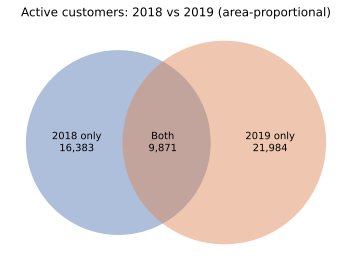

r = 1.1015   A_target = 1.1812   d = 1.1469


In [36]:
from matplotlib.patches import Circle
from scipy.optimize import brentq

# --- inputs from summary table ---
n2018 = summary.loc["Active 2018"].item()
n2019 = summary.loc["Active 2019"].item()
nboth = summary.loc["Active Both Years"].item()

# --- geometry, normalised so the 2018 circle has R = 1 ---
R = 1.0
r = np.sqrt(n2019 / n2018)            # 2019 radius, area-proportional
A_target = np.pi * (nboth / n2018)    # required overlap area

def lens_area(d, R, r):
    """Intersection area of two circles, radii R and r, centres d apart"""
    if d >= R + r:       return 0.0                   # disjoint
    if d <= abs(R - r):  return np.pi * min(R, r)**2  # one inside the other
    a1 = R**2 * np.arccos(np.clip((d**2 + R**2 - r**2) / (2*d*R), -1, 1))
    a2 = r**2 * np.arccos(np.clip((d**2 + r**2 - R**2) / (2*d*r), -1, 1))
    a3 = 0.5 * np.sqrt(max((-d+r+R)*(d-r+R)*(d+r-R)*(d+r+R), 0.0))
    return a1 + a2 - a3

# solve A(d) = A_target for the centre-to-centre distance
d = brentq(lambda d: lens_area(d, R, r) - A_target, a=abs(R - r) + 1e-9, b=R + r - 1e-9)

# --- draw ---
cy = max(R, r)
c1, c2 = (R, cy), (R + d, cy)         # 2018 and 2019 centres

fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(Circle(c1, R, facecolor="#4C72B0", edgecolor="none", alpha=0.45))
ax.add_patch(Circle(c2, r, facecolor="#DD8452", edgecolor="none", alpha=0.45))

x_lens = R + (d**2 + R**2 - r**2) / (2*d)   # x of the intersection chord
ax.text(c1[0] - 0.45*R, cy, f"2018 only\n{n2018 - nboth:,}", ha="center", va="center")
ax.text(x_lens,         cy, f"Both\n{nboth:,}",              ha="center", va="center")
ax.text(c2[0] + 0.45*r, cy, f"2019 only\n{n2019 - nboth:,}", ha="center", va="center")

ax.set_xlim(-0.2, R + d + r + 0.2)
ax.set_ylim(cy - r - 0.2, cy + r + 0.2)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Active customers: 2018 vs 2019 (area-proportional)")
plt.tight_layout()
plt.show()

print(f"r = {r:.4f}   A_target = {A_target:.4f}   d = {d:.4f}")

### Profit by Activity Group

Cross-tabulate `years` against 2018 profit and 2019 profit:

| Group | 2018 profit | 2019 profit |
|---|---|---|
| Both years | $1,216,397 | $1,183,778 |
| 2018 only | $1,073,946 | — |
| 2019 only | — | $1,615,125 |
| **Total** | **$2,290,295** | **$2,798,910** |

**Findings:** the both-years group produces **53% of 2018 profit but only 42% of 2019 profit**, and their profit *fell* by **≈ $32,618** year on year. Growth came entirely from acquisition. Repeat customers are over-represented in profit relative to their headcount share (38%/31%) — explain that gap with the AOF × AOV × Margin decomposition applied to each of the three groups (active customers, total trans, total spend, total profit → AOF, AOV, margin per group per year).

In [37]:
summary = (
    cust_2018_2019
    .groupby("Status")
    .agg(
        Y2018=("Profit_2018", lambda s: s.sum(min_count=1)),
        Y2019=("Profit_2019", lambda s: s.sum(min_count=1)),
    )
)

summary.loc["Total"] = summary.sum(min_count=1)

(
    GT(summary.reset_index(names="Group"))
    .tab_header(
        title="Profit by Activity Group"
    ).fmt_currency(
         columns=["Y2018", "Y2019"],
         decimals=0,
    ).tab_options(
            table_font_size="12px",
            data_row_padding="4px"
    )
)

GT(_tbl_data=                         Group       Y2018        Y2019
0           2018 Only (Lapsed)  1073945.75          NaN
1  2019 Only (New/Reactivated)         NaN  1615124.875
2            Active Both Years  1216397.00  1183778.750
3                        Total  2290342.75  2798903.500, _body=<great_tables._gt_data.Body object at 0x7dd90cccd220>, _boxhead=Boxhead([ColInfo(var='Group', type=<ColInfoTypeEnum.default: 1>, column_label='Group', column_align='left', column_width=None), ColInfo(var='Y2018', type=<ColInfoTypeEnum.default: 1>, column_label='Y2018', column_align='right', column_width=None), ColInfo(var='Y2019', type=<ColInfoTypeEnum.default: 1>, column_label='Y2019', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd90cc88500>, _spanners=Spanners([]), _heading=Heading(title='Profit by Activity Group', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd8fe6aa4d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd8fe6aa750>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd8fe8dad50>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd8fe6bfcf0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='12px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='v

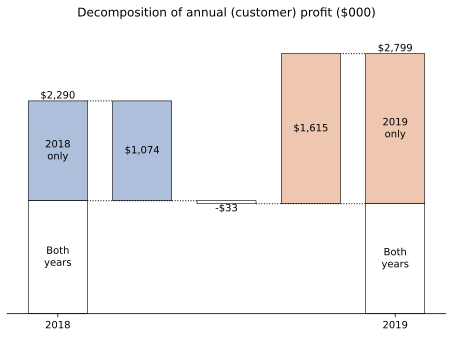

In [38]:
# --- pull the pieces out of your summary table (match your actual Status labels) ---
both_18 = summary.loc["Active Both Years", "Y2018"]
both_19 = summary.loc["Active Both Years", "Y2019"]
only_18 = summary.loc["2018 Only (Lapsed)", "Y2018"]
only_19 = summary.loc["2019 Only (New/Reactivated)", "Y2019"]
tot_18  = summary.loc["Total", "Y2018"]
tot_19  = summary.loc["Total", "Y2019"]

delta_both = both_19 - both_18 # change in the both-years group (-$33k)
lo_both = min(both_18, both_19) # baseline of the tiny middle bar

k = 1_000
money = lambda v: f"${v / k:,.0f}"

# Fills
solid  = dict(facecolor="white",   edgecolor="black", linewidth=0.6)  # both years
dotted = dict(facecolor=(0.298, 0.447, 0.690, 0.45), edgecolor="black", linewidth=0.6)  # 2018 side
dashed = dict(facecolor=(0.867, 0.518, 0.322, 0.45), edgecolor="black", linewidth=0.6)  # 2019 side
w = 0.7

fig, ax = plt.subplots(dpi=100)

# col 0 — 2018 total: both-years (bottom) + 2018-only (top)
ax.bar(0, both_18 / k, w, bottom=0, **solid)
ax.bar(0, only_18 / k, w, bottom=both_18 / k, **dotted)

# col 1 — the 2018-only profit leaving (floats on top of both-years)
ax.bar(1, only_18 / k, w, bottom=both_18 / k, **dotted)

# col 2 — the both-years group's own change (thin floating bar on the 1,183 line)
ax.bar(2, abs(delta_both) / k, w, bottom=lo_both / k, **solid)

# col 3 — the 2019-only profit arriving
ax.bar(3, only_19 / k, w, bottom=both_19 / k, **dashed)

# col 4 — 2019 total: both-years (bottom) + 2019-only (top)
ax.bar(4, both_19 / k, w, bottom=0, **solid)
ax.bar(4, only_19 / k, w, bottom=both_19 / k, **dashed)

# dotted connectors between the running levels
def hline(x0, x1, y):
    ax.plot([x0, x1], [y / k, y / k], ls=":", color="black", lw=1)

hline(0 + w/2, 1 - w/2, tot_18) # top: 2,290 -> 2018-only
hline(3 + w/2, 4 - w/2, tot_19) # top: 2019-only -> 2,799
hline(0 + w/2, 2 - w/2, both_18) # baseline 2018 side, out to delta bar
hline(2 + w/2, 4 - w/2, both_19) # baseline 2019 side, from delta bar on

# labels
ax.text(0, tot_18 / k, money(tot_18), ha="center", va="bottom")
ax.text(4, tot_19 / k, money(tot_19), ha="center", va="bottom")

ax.text(0, both_18 / 2 / k, "Both\nyears", ha="center", va="center")
ax.text(0, (both_18 + only_18 / 2) / k, "2018\nonly",  ha="center", va="center")
ax.text(4, both_19 / 2 / k, "Both\nyears", ha="center", va="center")
ax.text(4, (both_19 + only_19 / 2) / k, "2019\nonly",  ha="center", va="center")

ax.text(1, (both_18 + only_18 / 2) / k, money(only_18), ha="center", va="center")
ax.text(2, lo_both / k, f"-{money(abs(delta_both))}", ha="center", va="top")
ax.text(3, (both_19 + only_19 / 2) / k, money(only_19), ha="center", va="center")

# strip the chart down
ax.set_xticks([0, 4]); ax.set_xticklabels(["2018", "2019"])
ax.set_yticks([])
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.set_ylim(0, tot_19 / k * 1.12)
ax.set_xlim(-0.6, 4.6)
ax.set_title("Decomposition of annual (customer) profit ($000)")

plt.tight_layout()
plt.show()

In [39]:
flows = (
    cust_2018_2019
    .melt(
        id_vars=["CustomerID", "Status"],
        value_vars=["NumTrans_2018", "NumTrans_2019", "Spend_2018",
                      "Spend_2019", "Profit_2018", "Profit_2019"],
        var_name="MetricYear", value_name="Value"
    ).assign(
        Metric=lambda d: d["MetricYear"].str.rsplit("_", n=1).str[0],
        Year=lambda d: d["MetricYear"].str.rsplit("_", n=1).str[-1]
    )
)

# flows grid: sum with min_count=1 so all-NaN groups stay NaN
g = (
    flows
    .groupby(["Status", "Metric", "Year"])["Value"].sum(min_count=1)
    .unstack("Metric")
)        # rows = Status×Year, cols = the 3 flows

# headcount grid + derived ratios, all vectorized on the flow columns
g["NumCust"] = (
    flows
    .assign(active=lambda d: d["Value"].notna())
    .query("Metric == 'NumTrans'")
    .groupby(["Status", "Year"])["active"].sum()
    .where(lambda s: s > 0) # 0 → NaN in one move
)

g["AOF"] = g["NumTrans"] / g["NumCust"]
g["AOV"] = g["Spend"] / g["NumTrans"]
g["Margin"] = g["Profit"] / g["Spend"]

In [40]:
crosstab = (
    g.stack().rename("Value")
    .unstack("Year").reset_index()
    .rename(columns={"level_1": "Metric"})
)

(
    GT(crosstab, groupname_col="Status", rowname_col="Metric")
    .tab_header(
        title="Performance Summary & Decomposition",
        subtitle="By Customer Group and Year"
    ).tab_options(
        table_font_size="12px", 
        data_row_padding="4px"
    ).fmt_number(
        columns=["2018", "2019"], 
        decimals=2, 
        use_seps=True
    ).fmt_number(
        columns=["2018", "2019"],
        rows=lambda d: d["Metric"].isin(["NumCust", "NumTrans"]),
        decimals=0, use_seps=True
    ).fmt_currency(
        columns=["2018", "2019"],
        rows=lambda d: d["Metric"].isin(["Spend", "Profit"]),
        currency="USD", decimals=0
    ).fmt_percent(
        columns=["2018", "2019"],
        rows=lambda d: d["Metric"].eq("Margin"),
        decimals=1
    ).sub_missing(missing_text="")
)

GT(_tbl_data=Year                       Status    Metric          2018          2019
0              2018 Only (Lapsed)  NumTrans  2.297500e+04           NaN
1              2018 Only (Lapsed)    Profit  1.073946e+06           NaN
2              2018 Only (Lapsed)     Spend  2.227954e+06           NaN
3              2018 Only (Lapsed)   NumCust  1.638300e+04           NaN
4              2018 Only (Lapsed)       AOF  1.402368e+00           NaN
5              2018 Only (Lapsed)       AOV  9.697297e+01           NaN
6              2018 Only (Lapsed)    Margin  4.820323e-01           NaN
7     2019 Only (New/Reactivated)  NumTrans           NaN  3.316000e+04
8     2019 Only (New/Reactivated)    Profit           NaN  1.615125e+06
9     2019 Only (New/Reactivated)     Spend           NaN  3.346675e+06
10    2019 Only (New/Reactivated)   NumCust           NaN  2.198400e+04
11    2019 Only (New/Reactivated)       AOF           NaN  1.508370e+00
12    2019 Only (New/Reactivated)       AOV           NaN  1.009251e+02
13    2019 Only (New/Reactivated)    Margin           NaN  4.826058e-01
14              Active Both Years  NumTrans  2.781300e+04  2.757000e+04
15              Active Both Years    Profit  1.216397e+06  1.183779e+06
16              Active Both Years     Spend  2.587548e+06  2.490037e+06
17              Active Both Years   NumCust  9.871000e+03  9.871000e+03
18              Active Both Years       AOF  2.817648e+00  2.793030e+00
19              Active Both Years       AOV  9.303377e+01  9.031690e+01
20              Active Both Years    Margin  4.700963e-01  4.754061e-01, _body=<great_tables._gt_data.Body object at 0x7dd8fe797750>, _boxhead=Boxhead([ColInfo(var='Status', type=<ColInfoTypeEnum.row_group: 3>, column_label='Status', column_align='center', column_width=None), ColInfo(var='Metric', type=<ColInfoTypeEnum.stub: 2>, column_label='Metric', column_align='left', column_width=None), ColInfo(var='2018', type=<ColInfoTypeEnum.default: 1>, column_label='2018', column_align='right', column_width=None), ColInfo(var='2019', type=<ColInfoTypeEnum.default: 1>, column_label='2019', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd8fe6d1550>, _spanners=Spanners([]), _heading=Heading(title='Performance Summary & Decomposition', subtitle='By Customer Group and Year', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd8fe7282f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd8fe728360>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7dd8fe6d1a90>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7dd8fe9177f0>, <great_tables._gt_data.FormatInfo object at 0x7dd8fe90da30>, <great_tables._gt_data.FormatInfo object at 0x7dd90ccc9550>, <great_tables._gt_data.FormatInfo object at 0x7dd90cc377d0>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x7dd8fe728520>], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='

### Decile Change Analysis

Do high-value customers stay high-value?

1. Compute **profit-decile boundaries separately for 2018 and 2019** (same cumulative-profit method as §1.7b).
2. Compare them — in this dataset they come out very close. So use a **common set of cut-offs for both years**: average the two years' thresholds and round to the nearest $5, giving:
   - **545, 350, 255, 195, 150, 115, 90, 65, 40**
   - Decile 1 = profit > $545; decile 2 = (350, 545]; … decile 10 = ≤ $40 (including all negatives).

3. Assign every customer a 2018 decile and a 2019 decile using those cut-offs. Customers inactive in a year get profit 0 → decile 10, which is harmless because you filter by `years` before tabulating.
4. Build a 2018-decile × 2019-decile cross-tab **restricted to the `both` group** (9,871 customers).
5. Append a **`2018 only` column** (counts by 2018 decile, 16,383 customers) and a **`2019 only` row** (counts by 2019 decile, 21,984 customers).
6. Row totals as % of 26,254; column totals as % of 31,855.

**Trade-off to be explicit about:** common cut-offs mean each decile no longer holds exactly 10% of each year's profit. Year-specific cut-offs preserve the 10%-of-profit property but make the transition matrix harder to read. Analyst's call.

**Finding to expect:** heavy mass on the diagonal and just below it, plus a very large `2018 only` column concentrated in the low deciles — i.e. churn is heaviest among low-value customers, but decile 1 is not immune.

In [41]:
_, thresholds_2018, boundaries_2018 = decile_labels(cust_data_2018, "Profit", n=10)
_, thresholds_2019, boundaries_2019 = decile_labels(cust_data_2019, "Profit", n=10)

average_boundaries = np.round((boundaries_2019 + boundaries_2018)/2/5) * 5

def decile(s):
    v = s.to_numpy()
    out = 10 - np.searchsorted(average_boundaries[::-1], v, side="left")
    return np.where(np.isnan(v), np.nan, out)          # NaN stays NaN

tbl = (
    cust_2018_2019
    .assign(
        Row=lambda d: decile(d["Profit_2018"]),
        Col=lambda d: decile(d["Profit_2019"]),
    )
    .fillna({"Row": "2019 Only", "Col": "2018 Only"})
)

order_r = [*range(1, 11), "2019 Only"]
order_c = [*range(1, 11), "2018 Only"]

table = (
    pd.crosstab(tbl["Row"], tbl["Col"], margins=True, margins_name="Total")
    .reindex(index=[*order_r, "Total"], columns=[*order_c, "Total"], fill_value=0)
)

In [42]:
tbl = table.copy()
tbl.columns = [str(c) for c in tbl.columns]
tbl.index   = [str(i) for i in tbl.index]

# margins as percentages
tbl["% 2018"] = tbl["Total"] / cust_data_2018['CustomerID'].count()
tbl.loc[["2019 Only", "Total"], "% 2018"] = np.nan

tbl.loc["% 2019"] = tbl.loc["Total"] / cust_data_2019['CustomerID'].count()
tbl.loc["% 2019", ["2018 Only", "Total", "% 2018"]] = np.nan

tbl = tbl.reset_index(names="2018 decile")

decile_cols = [str(c) for c in range(1, 11)]
count_cols  = decile_cols + ["2018 Only", "Total"]

is_pct_row = lambda d: d["2018 decile"].eq("% 2019")
is_total   = lambda d: d["2018 decile"].eq("Total")

(
    GT(tbl, rowname_col="2018 decile")
    .tab_header(title="Profit Decile Change", subtitle="2018 to 2019")
    .tab_spanner(label="2019 decile", columns=decile_cols)
    .fmt_number(columns=count_cols, decimals=0, use_seps=True)
    .fmt_percent(columns=count_cols, rows=is_pct_row, decimals=1)
    .fmt_percent(columns="% 2018", decimals=1)
    .sub_missing(missing_text="")
    .data_color(
        columns=decile_cols,
        rows=lambda d: ~d["2018 decile"].isin(["2019 Only", "Total", "% 2019"]),
        palette=["#ffffff", "#c6dbef", "#4292c6", "#08306b"],
        # domain=[0, 300],
        na_color="white",
    )
    .tab_style(style=style.text(weight="bold"), locations=loc.body(rows=is_total))
    .tab_style(style=style.text(weight="bold"), locations=loc.body(columns=["Total"]))
    .tab_options(table_font_size="11px", data_row_padding="3px")
)

GT(_tbl_data=   2018 decile           1           2           3            4            5  \
0            1   67.000000   44.000000   29.000000    15.000000    18.000000   
1            2   33.000000   63.000000   65.000000    43.000000    45.000000   
2            3   19.000000   47.000000   61.000000    71.000000    55.000000   
3            4   21.000000   37.000000   53.000000    60.000000    60.000000   
4            5   23.000000   35.000000   58.000000    75.000000    77.000000   
5            6   21.000000   40.000000   53.000000    61.000000    98.000000   
6            7    8.000000   30.000000   44.000000    61.000000    68.000000   
7            8   13.000000   28.000000   61.000000    64.000000    84.000000   
8            9   15.000000   26.000000   48.000000    58.000000    90.000000   
9           10   11.000000   31.000000   58.000000    88.000000   118.000000   
10   2019 Only  115.000000  252.000000  451.000000   655.000000  1009.000000   
11       Total  346.000000  633.000000  981.000000  1251.000000  1722.000000   
12      % 2019    0.010862    0.019871    0.030796     0.039272     0.054057   

              6            7            8            9            10  \
0     15.000000    10.000000    11.000000     7.000000      8.000000   
1     29.000000    25.000000    29.000000    22.000000     43.000000   
2     51.000000    39.000000    56.000000    58.000000     65.000000   
3     63.000000    65.000000    84.000000    74.000000    110.000000   
4     79.000000    81.000000    79.000000    83.000000    146.000000   
5     77.000000    86.000000   106.000000   130.000000    199.000000   
6     75.000000    91.000000   128.000000   122.000000    231.000000   
7     98.000000   119.000000   161.000000   197.000000    349.000000   
8    129.000000   155.000000   200.000000   272.000000    568.000000   
9    181.000000   176.000000   305.000000   477.000000   1456.000000   
10  1442.000000  1661.000000  2672.000000  3951.000000   9776.000000   
11  2239.000000  2508.000000  3831.000000  5393.000000  12951.000000   
12     0.070287     0.078732     0.120264     0.169298      0.406561   

    2018 Only    Total    % 2018  
0        52.0    276.0  0.010513  
1       150.0    547.0  0.020835  
2       261.0    783.0  0.029824  
3       416.0   1043.0  0.039727  
4       591.0   1327.0  0.050545  
5       924.0   1795.0  0.068371  
6      1150.0   2008.0  0.076484  
7      1932.0   3106.0  0.118306  
8      3035.0   4596.0  0.175059  
9      7872.0  10773.0  0.410337  
10        0.0  21984.0       NaN  
11    16383.0  48238.0       NaN  
12        NaN      NaN       NaN  , _body=<great_tables._gt_data.Body object at 0x7dd8fa561590>, _boxhead=Boxhead([ColInfo(var='2018 decile', type=<ColInfoTypeEnum.stub: 2>, column_label='2018 decile', column_align='left', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='1', column_align='right', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='2', column_align='right', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='3', column_align='right', column_width=None), ColInfo(var='4', type=<ColInfoTypeEnum.default: 1>, column_label='4', column_align='right', column_width=None), ColInfo(var='5', type=<ColInfoTypeEnum.default: 1>, column_label='5', column_align='right', column_width=None), ColInfo(var='6', type=<ColInfoTypeEnum.default: 1>, column_label='6', column_align='right', column_width=None), ColInfo(var='7', type=<ColInfoTypeEnum.default: 1>, column_label='7', column_align='right', column_width=None), ColInfo(var='8', type=<ColInfoTypeEnum.default: 1>, column_label='8', column_align='right', column_width=None), ColInfo(var='9', type=<ColInfoTypeEnum.default: 1>, column_label='9', column_align='right', column_width=None), ColInfo(var='10', type=<ColInfoTypeEnum.default: 1>, column_label='10', column_align='right', column_width=None), ColInfo(var='2018 Only', type=<ColInf

### Up-down analysis

For the 9,871 customers active in both years, decompose profit change into its drivers.

For each customer, build four binary flags (define **Up = 2019 value ≥ 2018 value**):
- `profit_up`
- `trans_up`
- `aspt_up` — average spend per transaction (`spend/trans`)
- `margin_up` — (`profit/spend`)

Concatenate into a 4-bit pattern → 16 possible groups. Aggregate: customer count, total 2018 profit, total 2019 profit, and profit change per group. Add rows for `2018 only` (all profit lost) and `2019 only` (all profit new), then a total.

**Findings and gotchas:**
- **One customer has zero 2019 spend → undefined margin.** Drop them (analysis then covers 9,870) or force them into the Down-Down-Down-Down group.
- Only **14 of 16 groups** appear in this 1% sample. **Up-Down-Down-Down** and **Down-Up-Up-Up** are missing — but they are *logically possible*, not impossible: a loss-making customer who becomes less unprofitable can have profit Up while all three drivers are Down, and vice versa. In the full dataset there are 29 and 38 such customers respectively. **Don't hard-code 14 groups.**
- **The `≥` in the Up definition matters a lot for transactions.** Of the 6,524 customers labelled Up on transactions, **3,273 had the *same* transaction count in both years** — a third of the repeat base. Profit ties are rare (4 customers); spend ties are rare (41). **Recommendation: use three levels (Up / Same / Down) for transactions**, two for the rest.
- Largest positive contribution comes from Up-Up-Up-Up (~1,836 customers, +$221k); largest negative from Down-Down-Down-Down (~931 customers, –$170k). But the dominant swing factors overall are the 2018-only (–$1.07M) and 2019-only (+$1.62M) blocks.

In [43]:
both = (
    cust_2018_2019
    .query("Status == 'Active Both Years'")
    # margin is undefined when spend is 0 — the book drops this customer (9,871 -> 9,870)
    .query("Spend_2018 > 0 and Spend_2019 > 0")
    .assign(
        profit_up = lambda d: d["Profit_2019"]   >= d["Profit_2018"],
        trans_up  = lambda d: d["NumTrans_2019"] >= d["NumTrans_2018"],
        aspt_up   = lambda d: d["Spend_2019"] / d["NumTrans_2019"]
                            >= d["Spend_2018"] / d["NumTrans_2018"],
        margin_up = lambda d: d["Profit_2019"] / d["Spend_2019"]
                            >= d["Profit_2018"] / d["Spend_2018"],
    )
)

flags = ["profit_up", "trans_up", "aspt_up", "margin_up"]

grp = (
    both
    .groupby(flags, as_index=False)
    .agg(
        NumCust=("CustomerID", "count"),
        P2018=("Profit_2018", "sum"),
        P2019=("Profit_2019", "sum"),
    )
    .sort_values(flags, ascending=False)          # Up (True) before Down
    .assign(Change=lambda d: d["P2019"] - d["P2018"])
)

lbl = grp[flags].replace({True: "Up", False: "Down"})
body = pd.concat([lbl, grp[["NumCust", "P2018", "P2019", "Change"]]], axis=1)
body.columns = ["Profit", "# Trans", "ASPT", "Avg Marg",
                "# Customers", "2018", "2019", "Change"]

In [44]:
only18_n = (cust_2018_2019["Status"] == "2018 Only (Lapsed)").sum()
only19_n = (cust_2018_2019["Status"] == "2019 Only (New/Reactivated)").sum()
only18_p = cust_2018_2019.loc[cust_2018_2019["Status"] == "2018 Only (Lapsed)", "Profit_2018"].sum()
only19_p = cust_2018_2019.loc[cust_2018_2019["Status"] == "2019 Only (New/Reactivated)", "Profit_2019"].sum()

blank = {"Profit": "", "# Trans": "", "ASPT": ""}

tail = pd.DataFrame([
    {**blank, "Avg Marg": "", "# Customers": body["# Customers"].sum(),
     "2018": body["2018"].sum(), "2019": body["2019"].sum(),
     "Change": body["Change"].sum()},
    {**blank, "Avg Marg": "2018 only",  "# Customers": only18_n,
     "2018": only18_p, "2019": np.nan,   "Change": -only18_p},
    {**blank, "Avg Marg": "2019 only",  "# Customers": only19_n,
     "2018": np.nan,   "2019": only19_p, "Change": only19_p},
])
tail.loc[3] = {**blank, "Avg Marg": "Total",
               "# Customers": tail["# Customers"].sum(),
               "2018": tail["2018"].sum(), "2019": tail["2019"].sum(),
               "Change": tail["Change"].sum()}

tbl = pd.concat([body, tail], ignore_index=True)
n_body = len(body)

In [45]:
(
    GT(tbl)
    .tab_header(title="Up-Down Analysis",
                subtitle="Customers active in both 2018 and 2019")
    .tab_spanner(label="Profit", columns=["2018", "2019", "Change"])
    .fmt_number(columns="# Customers", decimals=0, use_seps=True)
    .fmt_currency(columns=["2018", "2019", "Change"], currency="USD", decimals=0)
    .sub_missing(missing_text="")
    .cols_align(align="center", columns=["Profit", "# Trans", "ASPT", "Avg Marg"])
    .tab_style(
        style=style.borders(sides="top", weight="2px"),
        locations=loc.body(rows=[n_body]),
    )
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.body(rows=[len(tbl) - 1]),
    )
    .tab_options(table_font_size="11px", data_row_padding="3px")
)

GT(_tbl_data=   Profit # Trans  ASPT   Avg Marg  # Customers          2018          2019  \
0      Up      Up    Up         Up         1836  1.039788e+05  3.254048e+05   
1      Up      Up    Up       Down         1212  7.724588e+04  1.941923e+05   
2      Up      Up  Down         Up          714  6.871730e+04  1.235704e+05   
3      Up      Up  Down       Down          510  5.262754e+04  9.312892e+04   
4      Up    Down    Up         Up          336  3.736110e+04  5.271213e+04   
5      Up    Down    Up       Down          118  1.529740e+04  2.040789e+04   
6      Up    Down  Down         Up           17  3.630100e+02  6.929300e+02   
7    Down      Up    Up       Down          163  8.925910e+03  7.395710e+03   
8    Down      Up  Down         Up          812  8.964803e+04  5.603487e+04   
9    Down      Up  Down       Down         1277  1.498403e+05  8.155702e+04   
10   Down    Down    Up         Up          529  9.487647e+04  5.794187e+04   
11   Down    Down    Up       Down          485  8.981635e+04  4.874977e+04   
12   Down    Down  Down         Up          930  2.029382e+05  6.761500e+04   
13   Down    Down  Down       Down          931  2.247128e+05  5.438165e+04   
14                                         9870  1.216349e+06  1.183785e+06   
15                       2018 only        16383  1.073946e+06           NaN   
16                       2019 only        21984           NaN  1.615125e+06   
17                           Total        48237  2.290295e+06  2.798910e+06   

          Change  
0   2.214260e+05  
1   1.169464e+05  
2   5.485312e+04  
3   4.050138e+04  
4   1.535103e+04  
5   5.110490e+03  
6   3.299200e+02  
7  -1.530200e+03  
8  -3.361316e+04  
9  -6.828324e+04  
10 -3.693460e+04  
11 -4.106658e+04  
12 -1.353232e+05  
13 -1.703312e+05  
14 -3.256380e+04  
15 -1.073946e+06  
16  1.615125e+06  
17  5.086154e+05  , _body=<great_tables._gt_data.Body object at 0x7dd8fa5863f0>, _boxhead=Boxhead([ColInfo(var='Profit', type=<ColInfoTypeEnum.default: 1>, column_label='Profit', column_align='center', column_width=None), ColInfo(var='# Trans', type=<ColInfoTypeEnum.default: 1>, column_label='# Trans', column_align='center', column_width=None), ColInfo(var='ASPT', type=<ColInfoTypeEnum.default: 1>, column_label='ASPT', column_align='center', column_width=None), ColInfo(var='Avg Marg', type=<ColInfoTypeEnum.default: 1>, column_label='Avg Marg', column_align='center', column_width=None), ColInfo(var='# Customers', type=<ColInfoTypeEnum.default: 1>, column_label='# Customers', column_align='right', column_width=None), ColInfo(var='2018', type=<ColInfoTypeEnum.default: 1>, column_label='2018', column_align='right', column_width=None), ColInfo(var='2019', type=<ColInfoTypeEnum.default: 1>, column_label='2019', column_align='right', column_width=None), ColInfo(var='Change', type=<ColInfoTypeEnum.default: 1>, column_label='Change', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd8fa59c350>, _spanners=Spanners([SpannerInfo(spanner_id='Profit', spanner_level=0, spanner_label='Profit', spanner_units=None, spanner_pattern=None, vars=['2018', '2019', 'Change'], built=None)]), _heading=Heading(title='Up-Down Analysis', subtitle='Customers active in both 2018 and 2019', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd8fc515c70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dd8fc516930>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=[14], mask=None), grpname=None, colname='Profit', rownum=14, colnum=None, styles=[CellStyleBorders(sides='top', color='#000000', style='solid', weight='2px')]), StyleInfo(locname=LocBody(columns=None, rows=[14], mask=None), grpname=None, colname='# Trans', rownum=14, colnum=None, styles=[CellStyleBorders(sides='top', color='#000000', style='solid', weight='2px')]), StyleInfo(locname=LocBody(columns=None, rows=[14], mask=None), grpname=No

In [46]:
for label, up, tie in [
    ("Profit",       both["Profit_2019"]   >=  both["Profit_2018"],
                     both["Profit_2019"]   == both["Profit_2018"]),
    ("Transactions", both["NumTrans_2019"] >=  both["NumTrans_2018"],
                     both["NumTrans_2019"] == both["NumTrans_2018"]),
    ("Spend",        both["Spend_2019"]    >=  both["Spend_2018"],
                     both["Spend_2019"]    == both["Spend_2018"]),
]:
    print(f"{label:<13} -> increased (or tied): {up.sum():>5,},  tied: {tie.sum():>5,}   "
          f"({tie.sum() / up.sum():.1%} of {up.sum():,})")

Profit        -> increased (or tied): 4,743,  tied:     4   (0.1% of 4,743)
Transactions  -> increased (or tied): 6,524,  tied: 3,273   (50.2% of 6,524)
Spend         -> increased (or tied): 4,769,  tied:    41   (0.9% of 4,769)


In [47]:
both = (
    cust_2018_2019
    .query("Status == 'Active Both Years'")
    .query("Spend_2018 > 0 and Spend_2019 > 0")
    .assign(
        profit_up  = lambda d: d["Profit_2019"]   >= d["Profit_2018"],
        trans_state= lambda d: np.sign(d["NumTrans_2019"] - d["NumTrans_2018"]).astype("int8"),
        aspt_up    = lambda d: d["Spend_2019"] / d["NumTrans_2019"]
                             >= d["Spend_2018"] / d["NumTrans_2018"],
        margin_up  = lambda d: d["Profit_2019"] / d["Spend_2019"]
                             >= d["Profit_2018"] / d["Spend_2018"],
    )
)

flags = ["profit_up", "trans_state", "aspt_up", "margin_up"]

grp = (
    both
    .groupby(flags, as_index=False)
    .agg(
        NumCust=("CustomerID", "count"),
        P2018=("Profit_2018", "sum"),
        P2019=("Profit_2019", "sum"),
    )
    .sort_values(flags, ascending=False)      # True>False, 1>0>-1
    .assign(Change=lambda d: d["P2019"] - d["P2018"])
)

bool_map = {True: "Up", False: "Down"}
tri_map  = {1: "Up", 0: "Same", -1: "Down"}

lbl = grp[flags].assign(
    profit_up  = lambda d: d["profit_up"].map(bool_map),
    trans_state= lambda d: d["trans_state"].map(tri_map),
    aspt_up    = lambda d: d["aspt_up"].map(bool_map),
    margin_up  = lambda d: d["margin_up"].map(bool_map),
)

body = pd.concat([lbl, grp[["NumCust", "P2018", "P2019", "Change"]]], axis=1)
body.columns = ["Profit", "# Trans", "ASPT", "Avg Marg",
                "# Customers", "2018", "2019", "Change"]

only18_n = (cust_2018_2019["Status"] == "2018 Only (Lapsed)").sum()
only19_n = (cust_2018_2019["Status"] == "2019 Only (New/Reactivated)").sum()
only18_p = cust_2018_2019.loc[cust_2018_2019["Status"] == "2018 Only (Lapsed)", "Profit_2018"].sum()
only19_p = cust_2018_2019.loc[cust_2018_2019["Status"] == "2019 Only (New/Reactivated)", "Profit_2019"].sum()

blank = {"Profit": "", "# Trans": "", "ASPT": ""}

tail = pd.DataFrame([
    {**blank, "Avg Marg": "", "# Customers": body["# Customers"].sum(),
     "2018": body["2018"].sum(), "2019": body["2019"].sum(),
     "Change": body["Change"].sum()},
    {**blank, "Avg Marg": "2018 only",  "# Customers": only18_n,
     "2018": only18_p, "2019": np.nan,   "Change": -only18_p},
    {**blank, "Avg Marg": "2019 only",  "# Customers": only19_n,
     "2018": np.nan,   "2019": only19_p, "Change": only19_p},
])
tail.loc[3] = {**blank, "Avg Marg": "Total",
               "# Customers": tail["# Customers"].sum(),
               "2018": tail["2018"].sum(), "2019": tail["2019"].sum(),
               "Change": tail["Change"].sum()}

tbl = pd.concat([body, tail], ignore_index=True)
n_body = len(body)

(
    GT(tbl)
    .tab_header(title="Up-Down Analysis",
                subtitle="Customers active in both 2018 and 2019")
    .tab_spanner(label="Profit", columns=["2018", "2019", "Change"])
    .fmt_number(columns="# Customers", decimals=0, use_seps=True)
    .fmt_currency(columns=["2018", "2019", "Change"], currency="USD", decimals=0)
    .sub_missing(missing_text="")
    .cols_align(align="center", columns=["Profit", "# Trans", "ASPT", "Avg Marg"])
    .tab_style(
        style=style.borders(sides="top", weight="2px"),
        locations=loc.body(rows=[n_body]),
    )
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.body(rows=[len(tbl) - 1]),
    )
    .tab_options(table_font_size="11px", data_row_padding="3px")
)

GT(_tbl_data=   Profit # Trans  ASPT   Avg Marg  # Customers          2018          2019  \
0      Up      Up    Up         Up          911  5.775230e+04  2.297231e+05   
1      Up      Up    Up       Down          675  4.993097e+04  1.469760e+05   
2      Up      Up  Down         Up          600  6.336983e+04  1.171165e+05   
3      Up      Up  Down       Down          510  5.262754e+04  9.312892e+04   
4      Up    Same    Up         Up          925  4.622650e+04  9.568172e+04   
5      Up    Same    Up       Down          537  2.731491e+04  4.721632e+04   
6      Up    Same  Down         Up          114  5.347470e+03  6.453890e+03   
7      Up    Down    Up         Up          336  3.736110e+04  5.271213e+04   
8      Up    Down    Up       Down          118  1.529740e+04  2.040789e+04   
9      Up    Down  Down         Up           17  3.630100e+02  6.929300e+02   
10   Down      Up    Up       Down           11  3.294000e+02  8.639001e+01   
11   Down      Up  Down         Up          165  2.712843e+04  1.947486e+04   
12   Down      Up  Down       Down          379  6.323600e+04  4.070824e+04   
13   Down    Same    Up       Down          152  8.596510e+03  7.309320e+03   
14   Down    Same  Down         Up          647  6.251960e+04  3.656001e+04   
15   Down    Same  Down       Down          898  8.660427e+04  4.084878e+04   
16   Down    Down    Up         Up          529  9.487647e+04  5.794187e+04   
17   Down    Down    Up       Down          485  8.981635e+04  4.874977e+04   
18   Down    Down  Down         Up          930  2.029382e+05  6.761500e+04   
19   Down    Down  Down       Down          931  2.247128e+05  5.438165e+04   
20                                         9870  1.216349e+06  1.183785e+06   
21                       2018 only        16383  1.073946e+06           NaN   
22                       2019 only        21984           NaN  1.615125e+06   
23                           Total        48237  2.290295e+06  2.798910e+06   

          Change  
0   1.719708e+05  
1   9.704498e+04  
2   5.374670e+04  
3   4.050138e+04  
4   4.945522e+04  
5   1.990141e+04  
6   1.106420e+03  
7   1.535103e+04  
8   5.110490e+03  
9   3.299200e+02  
10 -2.430100e+02  
11 -7.653570e+03  
12 -2.252776e+04  
13 -1.287190e+03  
14 -2.595959e+04  
15 -4.575549e+04  
16 -3.693460e+04  
17 -4.106658e+04  
18 -1.353232e+05  
19 -1.703312e+05  
20 -3.256383e+04  
21 -1.073946e+06  
22  1.615125e+06  
23  5.086152e+05  , _body=<great_tables._gt_data.Body object at 0x7dd8fa07ac60>, _boxhead=Boxhead([ColInfo(var='Profit', type=<ColInfoTypeEnum.default: 1>, column_label='Profit', column_align='center', column_width=None), ColInfo(var='# Trans', type=<ColInfoTypeEnum.default: 1>, column_label='# Trans', column_align='center', column_width=None), ColInfo(var='ASPT', type=<ColInfoTypeEnum.default: 1>, column_label='ASPT', column_align='center', column_width=None), ColInfo(var='Avg Marg', type=<ColInfoTypeEnum.default: 1>, column_label='Avg Marg', column_align='center', column_width=None), ColInfo(var='# Customers', type=<ColInfoTypeEnum.default: 1>, column_label='# Customers', column_align='right', column_width=None), ColInfo(var='2018', type=<ColInfoTypeEnum.default: 1>, column_label='2018', column_align='right', column_width=None), ColInfo(var='2019', type=<ColInfoTypeEnum.default: 1>, column_label='2019', column_align='right', column_width=None), ColInfo(var='Change', type=<ColInfoTypeEnum.default: 1>, column_label='Change', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dd8fa59cd10>, _spanners=Spanners([SpannerInfo(spanner_id='Profit', spanner_level=0, spanner_label='Profit', spanner_units=None, spanner_pattern=None, vars=['2018', '2019', 'Change'], built=None)]), _heading=Heading(title='Up-Down Analysis', subtitle='Customers active in both 2018 and 2019', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dd8fa56d070>, _summary_rows_grand=<g

## Lens 3 — How does a cohort evolve? (Q1/2016 cohort)

**Objective:** track one acquisition cohort across its lifetime. Cohort = customers whose first-ever purchase was in Q1/2016.

**Cohort size: 2,944 customers.** (Quarterly granularity means TCBA Figures 5.1 and 5.8, which need weekly/daily data, can't be reproduced.)

### Working dataset A — quarterly cohort summary

Filter long data to `Cohort == 'y2016 q1'`, group by `YearQuarter`: number of active cohort members, total transactions, total spend, total profit. 16 rows.

In [48]:
cohort_y2016_q1 = (
    cust_data
    .query("Cohort == 'y2016_q1'")
    .groupby(["Year", "Quarter"])
    .agg(
        ActiveCust=("CustomerID", "count"),
        TotalTrans=("NumTrans", "sum"),
        TotalSpend=("Spend", "sum"),
        TotalProfit=("Profit", "sum"),
    )
)

### Revenue decomposition over time

```
Revenue_t = cohort size × %active_t × ASPAC_t
ASPAC_t   = AOF_t × AOV_t
```
Plot each component by quarter:
- **Cohort revenue** — massive drop in the quarter *after* acquisition, then slow decline with a mild Q4 seasonal bump each year.
- **% active** — `active_t / cohort_size`. Same cliff.
- **ASPAC** — `spend_t / active_t`.
- **AOF** — `trans_t / active_t`. (In the 1% sample, AOF seasonality is much weaker than in the full dataset — a sampling artefact worth noting.)
- **AOV** — `spend_t / trans_t`.

The point of the decomposition: revenue decay is driven overwhelmingly by **% active** collapsing, not by spend-per-active-buyer eroding.

In [49]:
cohort_size = cohort_y2016_q1.xs((2016, 1))['ActiveCust']

cohort_y2016_q1 = (
    cohort_y2016_q1
    .assign(
        Pct_Active=cohort_y2016_q1['ActiveCust'] / cohort_size,
        ASPAC=cohort_y2016_q1['TotalSpend'] / cohort_y2016_q1['ActiveCust'] / 100,
        AOF=cohort_y2016_q1['TotalTrans'] / cohort_y2016_q1['ActiveCust'],
        AOV=cohort_y2016_q1['TotalSpend'] / cohort_y2016_q1['TotalTrans'] / 100,
    )
)

In [50]:
plot_df = (
    cohort_y2016_q1
    .reset_index()
    .assign(
        Period=lambda d: (d['Year'] - 2016) * 4 + (d['Quarter'] - 1),
        TotalSpend=lambda d: d["TotalSpend"]/100
    )
)

specs = {
    'TotalSpend': ('Total Spend',         '$,.0f'),
    'Pct_Active': ('% Active',              '.0%'),
    'ASPAC':      ('Avg. Spend per Active',  '$,.0f'),
    'AOF':        ('Avg. Order Frequency',   '.2f'),
    'AOV':        ('Avg. Order Value',       '$,.0f'),
}

def line(col, title, fmt):
    return (
        alt.Chart(plot_df)
        .mark_line(strokeWidth=1.2, point=alt.OverlayMarkDef(size=20, filled=True))
        .encode(
            x=alt.X('Period:Q', title='Quarters since acquisition',
                    axis=alt.Axis(tickMinStep=1, grid=False)),
            y=alt.Y(f'{col}:Q', title=title, axis=alt.Axis(format=fmt, grid=False)),
            tooltip=[alt.Tooltip('Period:Q'), alt.Tooltip(f'{col}:Q', format=fmt)],
        ).properties(width=500, height=300, title=title)
    )

charts = {col: line(col, title, fmt) for col, (title, fmt) in specs.items()}

for c in charts.values():
    display(c)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

### Annual repeat-buying patterns

Build a customer × quarter transaction matrix for the cohort, then collapse to four annual binary flags:

- **2016 flag** = 1 if the customer made **more than one** transaction in 2016 (i.e. at least one *repeat* purchase beyond the acquisition purchase). *This year is special — do not use `> 0`.*
- **2017 / 2018 / 2019 flags** = 1 if any transaction in that year.

Concatenate to a 4-bit pattern → 16 groups; report count and % of cohort per pattern, sorted descending.

**Headline finding: 45% of the Q1/2016 cohort never made a second purchase by the end of 2019.** The "always on" pattern (Y-Y-Y-Y) is ~8%.

Present the table with Y/N rather than 1/0 — audiences parse it faster.

In [78]:
cohort_y2016_q1 = (
    cust_data
    .query("Cohort == 'y2016_q1'")
    .pivot_table(
        index="CustomerID",
        columns="Year",
        values="NumTrans",
        aggfunc="sum",
        fill_value=0,
    )
)

first = cohort_y2016_q1.columns.min()
thresholds = pd.Series(1, index=cohort_y2016_q1.columns).mask(cohort_y2016_q1.columns != first, 0)
cohort_y2016_q1 = cohort_y2016_q1.gt(thresholds).rename(columns=str)

years = list(cohort_y2016_q1.columns)

grp = (
    cohort_y2016_q1
    .reset_index()
    .groupby(years, as_index=False)
    .agg(NumCust=("CustomerID", "count"))
    .sort_values(years, ascending=False)
    .reset_index(drop=True)                      # <- add this
    .assign(Pct=lambda d: d["NumCust"] / d["NumCust"].sum())
)


bool_map = {True: "Y", False: "N"}

body = pd.concat(
    [grp[years].replace(bool_map), grp[["NumCust", "Pct"]]],
    axis=1,
)

tail = pd.DataFrame([{
    **{c: "" for c in years[:-1]},
    years[-1]: "Total",
    "NumCust": body["NumCust"].sum(),
    "Pct": body["Pct"].sum(),
}])

tbl = pd.concat([body, tail], ignore_index=True)
n_body = len(body)

(
    GT(tbl)
    .tab_header(title="Cohort Annual Repeat-Buying Patterns",
                subtitle=f"Customers acquired in 2016 Q1 (n = {len(cohort_y2016_q1):,})")
    .tab_spanner(label="Active in year", columns=years)
    .fmt_number(columns="NumCust", decimals=0, use_seps=True)
    .fmt_percent(columns="Pct", decimals=1)
    .cols_label(NumCust="# Customers", Pct="% of Cohort")
    .cols_align(align="center", columns=years)
    .tab_style(style=style.borders(sides="top", weight="2px"),
               locations=loc.body(rows=[n_body]))
    .tab_style(style=style.text(weight="bold"),
               locations=loc.body(rows=[len(tbl) - 1]))
    .tab_options(table_font_size="11px", data_row_padding="3px")
)

GT(_tbl_data=   2016 2017 2018   2019  NumCust       Pct
0     Y    Y    Y      Y      229  0.077785
1     Y    Y    Y      N       82  0.027853
2     Y    Y    N      Y       45  0.015285
3     Y    Y    N      N      127  0.043139
4     Y    N    Y      Y       69  0.023438
5     Y    N    Y      N       74  0.025136
6     Y    N    N      Y       51  0.017323
7     Y    N    N      N      434  0.147418
8     N    Y    Y      Y       62  0.021060
9     N    Y    Y      N       44  0.014946
10    N    Y    N      Y       30  0.010190
11    N    Y    N      N      132  0.044837
12    N    N    Y      Y       47  0.015965
13    N    N    Y      N       99  0.033628
14    N    N    N      Y       89  0.030231
15    N    N    N      N     1330  0.451766
16                 Total     2944  1.000000, _body=<great_tables._gt_data.Body object at 0x7dedd123b890>, _boxhead=Boxhead([ColInfo(var='2016', type=<ColInfoTypeEnum.default: 1>, column_label='2016', column_align='center', column_width=None), ColInfo(var='2017', type=<ColInfoTypeEnum.default: 1>, column_label='2017', column_align='center', column_width=None), ColInfo(var='2018', type=<ColInfoTypeEnum.default: 1>, column_label='2018', column_align='center', column_width=None), ColInfo(var='2019', type=<ColInfoTypeEnum.default: 1>, column_label='2019', column_align='center', column_width=None), ColInfo(var='NumCust', type=<ColInfoTypeEnum.default: 1>, column_label='# Customers', column_align='right', column_width=None), ColInfo(var='Pct', type=<ColInfoTypeEnum.default: 1>, column_label='% of Cohort', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7dedd0168200>, _spanners=Spanners([SpannerInfo(spanner_id='Active in year', spanner_level=0, spanner_label='Active in year', spanner_units=None, spanner_pattern=None, vars=['2016', '2017', '2018', '2019'], built=None)]), _heading=Heading(title='Cohort Annual Repeat-Buying Patterns', subtitle='Customers acquired in 2016 Q1 (n = 2,944)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7dedc3c0ee10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7dedc3c0ee70>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=[16], mask=None), grpname=None, colname='2016', rownum=16, colnum=None, styles=[CellStyleBorders(sides='top', color='#000000', style='solid', weight='2px')]), StyleInfo(locname=LocBody(columns=None, rows=[16], mask=None), grpname=None, colname='2017', rownum=16, colnum=None, styles=[CellStyleBorders(sides='top', color='#000000', style='solid', weight='2px')]), StyleInfo(locname=LocBody(columns=None, rows=[16], mask=None), grpname=None, colname='2018', rownum=16, colnum=None, styles=[CellStyleBorders(sides='top', color='#000000', style='solid', weight='2px')]), StyleInfo(locname=LocBody(columns=None, rows=[16], mask=None), grpname=None, colname='2019', rownum=16, colnum=None, styles=[CellStyleBorders(sides='top', color='#000000', style='solid', weight='2px')]), StyleInfo(locname=LocBody(columns=None, rows=[16], mask=None), grpname=None, colname='NumCust', rownum=16, colnum=None, styles=[CellStyleBorders(sides='top', color='#000000', style='solid', weight='2px')]), StyleInfo(locname=LocBody(columns=None, rows=[16], mask=None), grpname=None, colname='Pct', rownum=16, colnum=None, styles=[CellStyleBorders(sides='top', color='#000000', style='solid', weight='2px')]), StyleInfo(locname=LocBody(columns=None, rows=[16], mask=None), grpname=None, colname='2016', rownum=16, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[16], mask=None), grpname=None, colname='2017', rownum=16, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=No

### Time to second purchase

From the same customer × quarter matrix, build a cumulative "has made a second-ever purchase" indicator:

- Quarter 1 (acquisition quarter): `1 if trans_q1 > 1 else 0`
- Quarter t > 1: `max(indicator_{t-1}, 1 if trans_t > 0 else 0)`

Column sums ÷ cohort size → **cumulative % of cohort having made a second purchase** by end of each quarter. First differences → **% making their second purchase *in* each quarter**.

### 3.5 Quarterly repeat-buying rate *(optional; not in TCBA)*
Definition: % of customers active in period *t* who are also active in period *t+1*.

Build a customer × quarter binary activity matrix (`trans > 0`), then:
```
RBR_t = Σ (active_t × active_{t+1}) / Σ active_t
```
(i.e. dot product of adjacent columns over the sum of the earlier column.)

**Conceptual distinction:** RBR is a period-to-period measure and is blind to within-period repeat purchases. A customer who bought five times in Q1/2016 and never again shows up as a repeat buyer in §3.4 but *not* in the RBR series. Both measures are needed.

### 3.6 Working dataset B — value to date (VTD)
Group the cohort's records by `CustomerID` across all 16 quarters: total transactions, total spend, total profit. **VTD = total (undiscounted) profit over 2016–2019.** 2,944 rows.

**Findings:** VTD ranges **–$23 to $3,756**. Mean **$170**, median **$78** → **72% of cohort members are below average**. 5th pct $5.56; 10th pct $12.05; top 5% above $663.09. Just over **2% have VTD > $1,000**. Total cohort VTD ≈ **$499,821**.

**Bins:** width $25, censor at $1,000.

### 3.7 VTD decile analysis
Same construction as the **profit decile report** (§1.7b), applied to VTD: each decile = 10% of the cohort's total VTD. Decile 1 cut-off ≈ **$1,373.43** (individual VTD).

Report per decile: % of cohort, % of transactions, % of spend, % of VTD, avg spend, avg VTD, AOF, AOV, margin.

**Key finding:** value concentration is driven by **frequency, not basket size**. AOF for decile 1 is ~**25×** decile 10's; AOV is only ~**2×**. High-value customers are high-value because they *come back*.

### 3.8 Annual % active by VTD decile
Cross the VTD decile label with the annual activity flags from §3.3 (but with 2016 set to 1 for everyone — by construction every cohort member was active in their acquisition year). Report, for each decile, the % of its members active in 2016, 2017, 2018, 2019.

This is the follow-through on §3.7: the top deciles stay alive; the bottom deciles vanish after year one.

### 3.9 RFM analysis
Computed at the end of the 4-year window, on the cohort.

- **R (recency)** = index of the last quarter with a transaction, 1 (Q1/2016) … 16 (Q4/2019).
- **F (frequency)** = total transactions over the four years.
- **M (monetary value)** = **average profit per transaction** = total profit / total transactions. *(Note: this is the book's definition. Other definitions exist — state yours.)*

Bins:
| Dim | Bins |
|---|---|
| R | 1 = Q1/2016 only; 2 = Q2/2016–Q4/2017 (q2–q8); 3 = Q1/2018–Q3/2019 (q9–q15); 4 = Q4/2019 |
| F | 1 = one purchase; 2 = 2–4; 3 = 5–10; 4 = 11+ |
| M | 1 = ≤ $25; 2 = ($25, $50]; 3 = ($50, $75]; 4 = > $75 |

Cross-tab: rows = R × M, columns = F.

**Structural note:** 4×4×4 = 64 cells, but only **52 are feasible** — a customer with F = 1 made their only purchase in the acquisition quarter, so **F = 1 implies R = 1**. Twelve cells (F=1 with R ∈ {2,3,4}) are structurally empty. Don't treat them as zeros to be explained.

Bin boundaries are judgment calls. The two that are near-mandatory: a **standalone F = 1 bin**, and **standalone recency bins for the first and last periods**.

---

## 4. Lens 4 — Comparing cohorts

**Objective:** compare and contrast the performance of different acquisition cohorts, controlling for cohort size.

### Working dataset
Four **cohort × quarter** matrices (17 quarterly cohorts incl. `pre 2016`, by 16 quarters):
1. number of active customers
2. total transactions
3. total spend
4. total profit

**Cohort size** = the diagonal of matrix (1) — the acquisition quarter's active count. **Exclude the `pre 2016` row** from anything requiring cohort size.

Then derive three more matrices:
- **% active** = active / cohort size *(quarterly cohorts only)*
- **AOF** = trans / active *(all cohorts, incl. pre-2016)*
- **AOV** = spend / trans
- **Avg margin** = profit / spend

### 4.1 Cohort comparison workflow (Q3/2016 vs Q4/2016)
Cohort sizes: **Q3/2016 = 2,842**, **Q4/2016 = 6,162** — more than 2× apart, so raw comparison is meaningless.

1. **Plot raw quarterly profit** for both cohorts. Q4 dominates simply because it's bigger.
2. **Index each cohort's profit to its own acquisition-quarter profit** (= 100). This normalises for size — but it still tells you *nothing about why* one decays faster than the other.
3. **Decompose.** Plot, for each cohort, on the same axes:
   - % cohort active by quarter
   - AOF by quarter
   - AOV by quarter
   - average margin by quarter

   This is where the actual insight lives. The decomposition tells you whether a cohort underperforms because fewer of them come back, because they come back less often, because they spend less per order, or because they buy lower-margin goods. Those are four completely different problems with four completely different responses.

4. Repeat for **Q4/2016 vs Q4/2017** — a like-for-like seasonal comparison across years.

---

## 5. Lens 5 — Health of the customer base

**Objective:** firm-level view. Are we growing because the base is healthy, or because we're outrunning churn with acquisition?

### Working datasets
Annual cohorts: **pre-2016, 2016, 2017, 2018, 2019**. Derive each customer's `CohortYear` from their `Cohort` label (keep `pre y2016` as its own level; otherwise take the year part).

Four **annual cohort × calendar year** matrices (5 × 4):
1. **Number active** — count of cohort members with ≥1 transaction in that year. *(This is the awkward one: build a customer × year activity indicator first, then group by cohort year and sum.)*
2. **Total transactions**
3. **Total spend**
4. **Total profit**

Also keep a per-customer table: `CustomerID, trans_2016..trans_2019, CohortYear` — several later analyses need it.

**Validation targets — active customers by year:** 2016 = 20,673; 2017 = 21,434; 2018 = 26,254; 2019 = 31,855.

**Validation targets — total profit by year:** 2016 = $1,871,911; 2017 = $1,953,229; 2018 ≈ $2,290,343; 2019 ≈ $2,798,904.

### 5.1 Annual performance
- Bar chart: annual revenue and profit.
- **Stacked bar: annual profit by acquisition cohort.** This is the single most important picture in the audit.
- Bar chart: **new customers acquired each year** (the diagonal of matrix 1).

### 5.2 The two percentages that matter
For the profit-by-cohort stack, annotate two different ratios — they answer different questions.

**(a) Share of a year's profit from that year's new customers.**
2016: $1,193,524 / $1,871,911 = **64%** → 36% of 2016 profit came from customers acquired earlier.

**(b) Year-on-year retention of profit from existing cohorts.**
Profit in 2017 from all cohorts acquired *before* 2017 = $1,953,229 – $964,671 = $988,558.
That's **53%** of what those same cohorts delivered in 2016 ($1,871,911).

And per-cohort:
- The 2016 cohort delivered $1,193,524 in 2016 and $451,670 in 2017 → **38%** retention of profit.
- The pre-2016 cohort delivered $678,387 in 2016 and $536,888 in 2017 → **79%** retention.

**The story:** new cohorts decay fast (38% in year two); old, self-selected surviving cohorts are far stickier (79%). Growth in total profit is being bought with acquisition, while the profit contributed by each existing cohort falls roughly by half annually. Repeat the same annotation for the active-customer stack.

### 5.3 Time to second purchase, by annual cohort
Cumulative % of each annual cohort that has made a second-ever purchase by end of each year.

Logic per customer × year cell:
- 0 if the year precedes the cohort year
- if year == cohort year: `1 if trans > 1 else 0` (repeat beyond the acquisition purchase)
- if year > cohort year: `max(previous_flag, 1 if trans > 0 else 0)`

Sum by cohort year, divide by cohort size. **Exclude the `pre 2016` cohort** — its size is unknown and its "acquisition year" is outside the window.

Result is a triangular table (each cohort's series starts in its acquisition year).

### 5.4 Annual repeat-buying rate
```
RBR(cohort, x→x+1) = # cohort members active in BOTH year x and x+1
                     ÷ # cohort members active in year x
```
Build pairwise activity indicators (16/17, 17/18, 18/19) at the customer level, sum by cohort year, then divide by the corresponding column of matrix (1).

Report per cohort **and** overall (all customers, not split by cohort).

Rows: pre-2016, 2016, 2017, 2018, Overall. **There is no 2019 row** — you'd need 2020 data. Expect the pre-2016 cohort's RBR to be substantially higher than any new cohort's: survivorship, not superiority.

### 5.5 Full cohort decomposition by year
For each annual cohort × year:

| Table | Formula |
|---|---|
| **% active** | active / cohort size *(2016–2019 cohorts only; NaN for pre-2016)* |
| **Avg annual profit per active member** | profit / active |
| **Annual AOF** | trans / active |
| **Annual AOV** | spend / trans |
| **Annual avg margin** | profit / spend |

Plot each as a line chart, one line per cohort. Add a **Total** row (all customers) to each — the totals row of the last three gives you the **overall AOF, AOV and margin by year**, which is the firm-level summary of whether the business is changing shape.

**Note on plotting:** cells before a cohort exists must be **missing (NaN), not zero** — a zero will be plotted and will distort the line.

### 5.6 Quarterly version
Same three pictures, at quarterly granularity using quarterly cohorts (reuse the Lens 4 matrices):
1. Quarterly revenue and profit (column totals of the spend and profit matrices).
2. Quarterly profit **stacked by quarterly cohort** — the fine-grained version of §5.1.
3. Number of customers acquired each quarter (the diagonal).

---

## Appendix B — Implementation checklist

- [ ] Load long CSV once; derive `Year`; keep as the single source of truth.
- [ ] Write one reusable `describe_and_bin(series, width, cutoff, neg_bin=False)` helper — six of the histograms in Lens 1/3 are the same function with different arguments.
- [ ] Write one reusable `decile_report(df, value_col, method='customer'|'value')` — Lens 1 uses it twice, Lens 3 once.
- [ ] Write one reusable `decompose(df_grouped)` returning %cust / %trans / %spend / %profit / avg spend / avg profit / AOF / AOV / margin. Used in Lens 1, 2, 3, 4, 5.
- [ ] Guard every ratio against zero denominators (`Spend == 0` → margin undefined; `NumTrans == 0` → ASPT undefined). Two customers in 2019, one in the Lens 2 both-group. Do not silently zero-fill.
- [ ] Keep pre-2016 cohort in transaction/spend/profit aggregates but **out of** every cohort-size-denominated ratio.
- [ ] Use NaN (not 0) for cohort-year cells that pre-date the cohort's existence.
- [ ] Cross-check totals at every stage: 31,855 / 60,730 / $5.84M / $2.80M for 2019; 48,238 customers in the Lens 2 frame; 2,944 in the Q1/2016 cohort.